## 1. Setup and Imports

In [1]:
import os
import sys
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import json

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import confusion_matrix, classification_report

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
	print(f"Number of CUDA devices: {torch.cuda.device_count()}")
	for i in range(torch.cuda.device_count()):
		print(f"  Device {i}: {torch.cuda.get_device_name(i)}")

# Set device - auto-detect, with fallback to CPU
if torch.cuda.is_available():
	device = "cuda:0"  # Use first GPU if available
else:
	device = "cpu"
	
print(f"\nUsing device: {device}")

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.10.0+cu128
CUDA available: True
Number of CUDA devices: 2
  Device 0: NVIDIA RTX PRO 4000 Blackwell
  Device 1: NVIDIA RTX PRO 4000 Blackwell

Using device: cuda:0


In [2]:
cd /home/dmoi/projects/ESM3di/

/home/dmoi/projects/ESM3di


In [3]:
#!foldseek databases ProstT5 weights tmp

## Create Test Set from BFVD Data

Create a small test set from the BFVD structural tokens dataset for evaluation.

In [4]:
from esm3di.ESM3di_model import ESM3DiModel, read_fasta


def create_test_set_from_bfvd(
    aa_fasta_path: str, 
    three_di_fasta_path: str, 
    test_size: int = 100, 
    output_prefix: str = "test_data",
    random_seed: int = 42
) -> Tuple[str, str]:
    """
    Create a small test set from the BFVD dataset.
    
    Args:
        aa_fasta_path: Path to BFVD amino acid FASTA file
        three_di_fasta_path: Path to BFVD 3Di FASTA file (masked)
        test_size: Number of sequences to extract for test set
        output_prefix: Prefix for output files
        random_seed: Random seed for reproducible sampling
        
    Returns:
        Tuple of (test_aa_fasta_path, test_3di_fasta_path)
    """
    import random
    
    print(f"Creating test set from BFVD data...")
    print(f"Source AA FASTA: {aa_fasta_path}")
    print(f"Source 3Di FASTA: {three_di_fasta_path}")
    print(f"Test set size: {test_size}")
    print("-" * 80)
    
    # Set random seed for reproducibility
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    # Read the full BFVD dataset
    print("Loading BFVD amino acid sequences...")
    aa_records = read_fasta(aa_fasta_path)
    print(f"✓ Loaded {len(aa_records)} AA sequences")
    
    print("Loading BFVD 3Di sequences...")
    three_di_records = read_fasta(three_di_fasta_path)
    print(f"✓ Loaded {len(three_di_records)} 3Di sequences")
    
    # Verify they match
    if len(aa_records) != len(three_di_records):
        raise ValueError(f"Mismatch: {len(aa_records)} AA sequences vs {len(three_di_records)} 3Di sequences")
    
    # Create header mapping for verification
    aa_headers = {header: i for i, (header, _) in enumerate(aa_records)}
    three_di_headers = {header: i for i, (header, _) in enumerate(three_di_records)}
    
    # Find common headers (should be all if datasets are aligned)
    common_headers = set(aa_headers.keys()) & set(three_di_headers.keys())
    print(f"✓ Found {len(common_headers)} matching sequence headers")
    
    if len(common_headers) < test_size:
        raise ValueError(f"Not enough matching sequences ({len(common_headers)}) for test set size ({test_size})")
    
    # Sample random sequences for test set
    selected_headers = random.sample(list(common_headers), test_size)
    print(f"✓ Selected {len(selected_headers)} sequences for test set")
    
    # Extract selected sequences
    test_aa_records = []
    test_3di_records = []
    
    for header in selected_headers:
        aa_idx = aa_headers[header]
        three_di_idx = three_di_headers[header]
        
        test_aa_records.append(aa_records[aa_idx])
        test_3di_records.append(three_di_records[three_di_idx])
    
    # Generate output file paths
    test_aa_path = f"{output_prefix}_aa.fasta"
    test_3di_path = f"{output_prefix}_3di_masked.fasta"
    test_3di_unmasked_path = f"{output_prefix}_3di.fasta"
    
    # Write test AA sequences
    print(f"Writing test AA sequences to {test_aa_path}...")
    with open(test_aa_path, 'w') as f:
        for header, seq in test_aa_records:
            f.write(f">{header}\n")
            # Write in lines of 80 characters
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Write test 3Di sequences (masked version)
    print(f"Writing test 3Di sequences (masked) to {test_3di_path}...")
    with open(test_3di_path, 'w') as f:
        for header, seq in test_3di_records:
            f.write(f">{header}\n")
            # Write in lines of 80 characters  
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Create unmasked version by removing mask characters
    print(f"Creating unmasked 3Di sequences for {test_3di_unmasked_path}...")
    unmasked_records = []
    mask_chars = {'X', 'x', '-'}  # Common mask characters
    
    for header, masked_seq in test_3di_records:
        # Remove mask characters to create "ground truth" 3Di
        # Note: This assumes the masked sequence has real 3Di chars that we can unmask
        # You may need to adjust this logic based on your masking strategy
        unmasked_seq = ''.join([c for c in masked_seq if c not in mask_chars])
        
        # If the sequence becomes too short after unmasking, keep some context
        if len(unmasked_seq) < len(masked_seq) * 0.5:  # Less than 50% remained
            # Use original sequence but replace masks with a default character
            unmasked_seq = masked_seq.replace('X', 'L').replace('x', 'L').replace('-', 'L').replace('N', 'L').replace('n', 'L')
        
        unmasked_records.append((header, unmasked_seq))
    
    # Write unmasked version
    with open(test_3di_unmasked_path, 'w') as f:
        for header, seq in unmasked_records:
            f.write(f">{header}\n")
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Print statistics
    seq_lengths = [len(seq) for _, seq in test_aa_records]
    print(f"\n✓ Test set created successfully!")
    print(f"Files created:")
    print(f"  - {test_aa_path} (amino acid sequences)")
    print(f"  - {test_3di_path} (3Di sequences - masked)")
    print(f"  - {test_3di_unmasked_path} (3Di sequences - unmasked)")
    print(f"\nSequence statistics:")
    print(f"  - Count: {len(test_aa_records)}")
    print(f"  - Length range: {min(seq_lengths)}-{max(seq_lengths)} residues")
    print(f"  - Mean length: {np.mean(seq_lengths):.1f} residues")
    print(f"  - Random seed used: {random_seed}")
    
    return test_aa_path, test_3di_unmasked_path

print("✓ Test set creation function defined")

✓ Test set creation function defined


In [23]:
# Configuration for BFVD test set creation
BFVD_CONFIG = {
    #'aa_fasta': '/mnt/data1/bfvd/training_set/bfvd_data_aa.fasta',
    #'three_di_fasta': '/mnt/data1/bfvd/training_set/bfvd_data_3di_masked.fasta',
	'aa_fasta': '/mnt/data1/metavir_esm3di/metavr_aa.fa',
    'three_di_fasta': '/mnt/data1/metavr_3di.fa',
    'test_size': 500,  # Number of sequences for test set
    'output_prefix': 'test_data',  # Prefix for output files
    'random_seed': 42,  # For reproducible sampling
    'create_test_set': True,  # Set to False to skip test set creation
}

# Create test set from BFVD data
if BFVD_CONFIG['create_test_set']:
    print("Creating test set from BFVD structural tokens...")
    print("=" * 80)
    
    try:
        # Check if source files exist
        if not os.path.exists(BFVD_CONFIG['aa_fasta']):
            print(f"⚠ Warning: AA FASTA not found: {BFVD_CONFIG['aa_fasta']}")
            print("Please check the file path or mount point.")
        elif not os.path.exists(BFVD_CONFIG['three_di_fasta']):
            print(f"⚠ Warning: 3Di FASTA not found: {BFVD_CONFIG['three_di_fasta']}")
            print("Please check the file path or mount point.")
        else:
            # Create the test set
            test_aa_path, test_3di_path = create_test_set_from_bfvd(
                aa_fasta_path=BFVD_CONFIG['aa_fasta'],
                three_di_fasta_path=BFVD_CONFIG['three_di_fasta'],
                test_size=BFVD_CONFIG['test_size'],
                output_prefix=BFVD_CONFIG['output_prefix'],
                random_seed=BFVD_CONFIG['random_seed']
            )
            
            print(f"\n✓ Test set files ready for evaluation:")
            print(f"  - AA sequences: {test_aa_path}")
            print(f"  - 3Di sequences: {test_3di_path}")
            
            # Verify files were created
            if os.path.exists(test_aa_path) and os.path.exists(test_3di_path):
                print(f"✓ All test files created successfully!")
            else:
                print(f"⚠ Warning: Some test files may not have been created properly.")
                
    except Exception as e:
        print(f"✗ Error creating test set: {str(e)}")
        import traceback
        traceback.print_exc()
        print("\nFalling back to existing test files if available...")
        
else:
    print("⚠ Test set creation disabled in configuration")
    print("Using existing test files if available...")

print(f"\n{'='*80}")

Creating test set from BFVD structural tokens...
Creating test set from BFVD data...
Source AA FASTA: /mnt/data1/metavir_esm3di/metavr_aa.fa
Source 3Di FASTA: /mnt/data1/metavr_3di.fa
Test set size: 500
--------------------------------------------------------------------------------
Loading BFVD amino acid sequences...
✓ Loaded 748927 AA sequences
Loading BFVD 3Di sequences...
✓ Loaded 748927 3Di sequences
✓ Found 748927 matching sequence headers
✓ Selected 500 sequences for test set
Writing test AA sequences to test_data_aa.fasta...
Writing test 3Di sequences (masked) to test_data_3di_masked.fasta...
Creating unmasked 3Di sequences for test_data_3di.fasta...

✓ Test set created successfully!
Files created:
  - test_data_aa.fasta (amino acid sequences)
  - test_data_3di_masked.fasta (3Di sequences - masked)
  - test_data_3di.fasta (3Di sequences - unmasked)

Sequence statistics:
  - Count: 500
  - Length range: 29-2641 residues
  - Mean length: 209.6 residues
  - Random seed used: 42



## 2. Utility Functions

In [24]:
def load_checkpoint(checkpoint_path: str, device: str = "cpu"):
    """
    Load a model checkpoint and return model wrapper, tokenizer, and metadata.
    
    The returned model wrapper uses its own predict_from_fasta implementation
    to load weights and run inference.
    
    Returns:
        model_wrapper, tokenizer, label_vocab, mask_chars, config
    """
    from esm3di.ESM3di_model import is_t5_model
    from esm3di.ESM3di_model import ESM3DiModel
    
    print(f"Loading checkpoint: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    label_vocab = checkpoint["label_vocab"]
    mask_chars = checkpoint.get("mask_label_chars", "")
    args_dict = checkpoint.get("args", {})
    
    epoch = checkpoint.get("epoch", 0)
    loss = checkpoint.get("loss", 0.0)

    print(f"  Checkpoint: epoch {epoch}, loss: {loss:.4f}")
    print(f"  Label vocab size: {len(label_vocab)}")
    print(f"  Mask characters: {mask_chars}")

    hf_model_name = args_dict.get(
        "hf_model_name",
        args_dict.get("hf_model", "facebook/esm2_t33_650M_UR50D")
    )
    is_t5_ckpt = is_t5_model(hf_model_name)
    num_labels = len(label_vocab)
    use_cnn_head = args_dict.get("use_cnn_head", False)
    use_transformer_head = args_dict.get("use_transformer_head", False)
    use_iterative_transformer_head = args_dict.get("use_iterative_transformer_head", False)
    use_plddt_prediction_head = args_dict.get("use_plddt_prediction_head", False)
    plddt_num_bins = args_dict.get("plddt_num_bins", 10)
    plddt_prediction_mode = args_dict.get("plddt_prediction_mode", "classification")
    aux_track_num_bins = args_dict.get("aux_track_num_bins", None)
    lora_r = args_dict.get("lora_r", 8)
    lora_alpha = args_dict.get("lora_alpha", 16)
    lora_dropout = args_dict.get("lora_dropout", 0.05)
    lora_target_modules = checkpoint.get("lora_target_modules", None)
    cnn_num_layers = args_dict.get("cnn_num_layers", 2)
    cnn_kernel_size = args_dict.get("cnn_kernel_size", 3)
    cnn_dropout = args_dict.get("cnn_dropout", 0.1)
    transformer_head_dim = args_dict.get("transformer_head_dim", 256)
    transformer_head_layers = args_dict.get("transformer_head_layers", 2)
    transformer_head_dropout = args_dict.get("transformer_head_dropout", 0.1)
    transformer_head_num_heads = args_dict.get("transformer_head_num_heads", None)
    iterative_head_max_iterations = args_dict.get("iterative_head_max_iterations", 5)
    iterative_head_halt_threshold = args_dict.get("iterative_head_halt_threshold", 0.95)
    iterative_head_lambda_p = args_dict.get("iterative_head_lambda_p", 0.01)
    iterative_head_prior_p = args_dict.get("iterative_head_prior_p", 0.5)
    use_positional_encoding = args_dict.get("use_positional_encoding", True)
    use_hidden_state_feedback = args_dict.get("use_hidden_state_feedback", True)
    use_gru_gate = args_dict.get("use_gru_gate", False)

    print(f"  Base model: {hf_model_name}")
    print(f"  Model family: {'T5 encoder' if is_t5_ckpt else 'ESM/other encoder'}")
    print(f"  Use CNN head: {use_cnn_head}")
    if use_cnn_head:
        print(f"    CNN layers: {cnn_num_layers}, kernel: {cnn_kernel_size}, dropout: {cnn_dropout}")
    print(f"  LoRA config: r={lora_r}, alpha={lora_alpha}, dropout={lora_dropout}")

    if is_t5_ckpt:
        from esm3di.T5Model import T5ProteinModel
        model_wrapper = T5ProteinModel(
            hf_model_name=hf_model_name,
            num_labels=num_labels,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=lora_target_modules,
            use_cnn_head=use_cnn_head,
            cnn_num_layers=cnn_num_layers,
            cnn_kernel_size=cnn_kernel_size,
            cnn_dropout=cnn_dropout,
            use_transformer_head=use_transformer_head,
            transformer_head_dim=transformer_head_dim,
            transformer_head_layers=transformer_head_layers,
            transformer_head_dropout=transformer_head_dropout,
            transformer_head_num_heads=transformer_head_num_heads,
            use_iterative_transformer_head=use_iterative_transformer_head,
            iterative_head_max_iterations=iterative_head_max_iterations,
            iterative_head_halt_threshold=iterative_head_halt_threshold,
            iterative_head_lambda_p=iterative_head_lambda_p,
            iterative_head_prior_p=iterative_head_prior_p,
            use_positional_encoding=use_positional_encoding,
            use_hidden_state_feedback=use_hidden_state_feedback,
            use_gru_gate=use_gru_gate,
            use_plddt_prediction_head=use_plddt_prediction_head,
            plddt_num_bins=plddt_num_bins,
            plddt_prediction_mode=plddt_prediction_mode,
            aux_track_num_bins=aux_track_num_bins,
            half_precision=args_dict.get("half_precision", False),
            gradient_checkpointing=args_dict.get("gradient_checkpointing", False),
        )
    else:
        model_wrapper = ESM3DiModel(
            hf_model_name=hf_model_name,
            num_labels=num_labels,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=lora_target_modules,
            use_cnn_head=use_cnn_head,
            cnn_num_layers=cnn_num_layers,
            cnn_kernel_size=cnn_kernel_size,
            cnn_dropout=cnn_dropout,
            use_transformer_head=use_transformer_head,
            transformer_head_dim=transformer_head_dim,
            transformer_head_layers=transformer_head_layers,
            transformer_head_dropout=transformer_head_dropout,
            transformer_head_num_heads=transformer_head_num_heads,
            use_iterative_transformer_head=use_iterative_transformer_head,
            iterative_head_max_iterations=iterative_head_max_iterations,
            iterative_head_halt_threshold=iterative_head_halt_threshold,
            iterative_head_lambda_p=iterative_head_lambda_p,
            iterative_head_prior_p=iterative_head_prior_p,
            use_positional_encoding=use_positional_encoding,
            use_hidden_state_feedback=use_hidden_state_feedback,
            use_gru_gate=use_gru_gate,
            use_plddt_prediction_head=use_plddt_prediction_head,
            plddt_num_bins=plddt_num_bins,
            plddt_prediction_mode=plddt_prediction_mode,
            aux_track_num_bins=aux_track_num_bins,
        )

    tokenizer = None
    if hasattr(model_wrapper, "get_tokenizer") and callable(model_wrapper.get_tokenizer):
        tokenizer = model_wrapper.get_tokenizer()
    elif hasattr(model_wrapper, "tokenizer"):
        tokenizer = model_wrapper.tokenizer

    args_dict["is_t5_model"] = bool(is_t5_ckpt)
    print("✓ Checkpoint loaded successfully\n")
    
    return model_wrapper, tokenizer, label_vocab, mask_chars, args_dict

print("✓ Checkpoint loader function defined")

✓ Checkpoint loader function defined


In [ ]:
@torch.no_grad()
def batch_predict_from_fasta(
    input_fasta_path: str,
    output_fasta_path: str,
    model_checkpoint_path: str = None,
    batch_size: int = 4,
    device: str = None,
    output_confidence_fasta: str = None,
):
    """
    Batch prediction function that processes sequences in batches for improved efficiency.
    
    This function delegates inference to the model class predict_from_fasta.
    
    Args:
        input_fasta_path: Path to input FASTA file with amino acid sequences
        output_fasta_path: Path to write predicted 3Di sequences in FASTA format
        model_checkpoint_path: Path to model checkpoint for loading weights
        batch_size: Number of sequences to process in each batch
        device: Device to run inference on (e.g., 'cuda' or 'cpu')
        output_confidence_fasta: Optional path to write confidence scores in FASTA format

    Returns:
        List of prediction records
    """
    model_wrapper, _, _, _, _ = load_checkpoint(model_checkpoint_path, device=device)
    predictions = model_wrapper.predict_from_fasta(
        input_fasta_path=input_fasta_path,
        output_fasta_path=output_fasta_path,
        model_checkpoint_path=model_checkpoint_path,
        batch_size=batch_size,
        device=device,
        output_confidence_fasta=output_confidence_fasta,
    )
    return predictions


def predict_sequences_with_model(
    model_wrapper,
    aa_sequences: List[str],
    output_dir: str,
    model_checkpoint_path: str = None,
    batch_size: int = 1,
    device: str = None,
    output_confidence_fasta: str = None,
    cleanup: bool = True,
):
    """
    Predict 3Di sequences for a list of AA sequences using predict_from_fasta.
    """
    import uuid

    os.makedirs(output_dir, exist_ok=True)
    run_id = uuid.uuid4().hex[:8]
    input_fasta = os.path.join(output_dir, f"tmp_predict_{run_id}_aa.fasta")
    output_fasta = os.path.join(output_dir, f"tmp_predict_{run_id}_3di.fasta")

    with open(input_fasta, "w") as f:
        for i, seq in enumerate(aa_sequences):
            f.write(f">seq_{i}\n{seq}\n")

    try:
        predictions = model_wrapper.predict_from_fasta(
            input_fasta_path=input_fasta,
            output_fasta_path=output_fasta,
            model_checkpoint_path=model_checkpoint_path,
            batch_size=batch_size,
			max_tokens_per_batch=10000,  # Adjust as needed for memory constraints
            device=device,
            output_confidence_fasta=output_confidence_fasta,
        )
        pred_map = {p["header"]: p["pred_3di"] for p in predictions}
        ordered = []
        for i, seq in enumerate(aa_sequences):
            pred = pred_map.get(f"seq_{i}")
            ordered.append(pred if pred is not None else ("N" * len(seq)))
        return ordered
    finally:
        if cleanup:
            if os.path.exists(input_fasta):
                os.remove(input_fasta)
            if os.path.exists(output_fasta):
                os.remove(output_fasta)

print("✓ Batch prediction function defined")

✓ Batch prediction function defined


In [26]:
@torch.no_grad()
def predict_3di_prost5(
	aa_sequences: List[str],
	device: str = 'cpu',
	batch_size: int = 1,
	work_dir: Optional[str] = None,
	cleanup: bool = False,
) -> List[str]:
	"""
	Predict 3Di sequences using ProST T5 via FoldSeek pipeline.

	Uses a persistent working directory (not /tmp).
	"""
	# Kept for API compatibility with model-based predictors
	_ = (device, batch_size)

	import shutil
	import uuid

	# Resolve pipeline function at runtime (avoids undefined symbol warning in notebook static checks)
	pipeline_fn = globals().get("run_foldseek_prostT5_pipeline")
	if pipeline_fn is None:
		raise NameError("run_foldseek_prostT5_pipeline is not defined. Run the cell that defines it first.")

	# Use evaluation output dir if available, otherwise local folder
	base_dir = work_dir
	if base_dir is None:
		base_output = EVAL_CONFIG['output_dir'] if 'EVAL_CONFIG' in globals() else 'evaluation_results'
		base_dir = os.path.join(base_output, "prost5_runs")

	os.makedirs(base_dir, exist_ok=True)
	run_dir = os.path.join(base_dir, f"run_{uuid.uuid4().hex[:8]}")
	os.makedirs(run_dir, exist_ok=True)

	try:
		# Write input FASTA
		input_fasta = os.path.join(run_dir, "input_aa.fasta")
		with open(input_fasta, "w") as f:
			for i, seq in enumerate(aa_sequences):
				f.write(f">seq_{i}\n{seq}\n")

		print(f"Running FoldSeek pipeline on {len(aa_sequences)} sequences...")
		output_3di_fasta = pipeline_fn(
			input_fasta,
			output_dir=os.path.join(run_dir, "foldseek_db"),
		)

		if not os.path.exists(output_3di_fasta):
			print(f"⚠ Output FASTA file not found: {output_3di_fasta}")
			return ["N" * len(seq) for seq in aa_sequences]

		records = read_fasta(output_3di_fasta)
		pred_map = {h: s for h, s in records}

		# Preserve original input order
		preds = []
		for i, seq in enumerate(aa_sequences):
			p = pred_map.get(f"seq_{i}", "")
			preds.append(p if p else ("N" * len(seq)))

		print(f"✓ Successfully generated {len(preds)} 3Di predictions")
		return preds

	except FileNotFoundError as e:
		print(f"⚠ FoldSeek not found in PATH: {str(e)}")
		print("Please install FoldSeek: https://github.com/steineggerlab/foldseek")
		return ["N" * len(seq) for seq in aa_sequences]

	except Exception as e:
		print(f"⚠ Error in ProST T5 prediction: {str(e)}")
		import traceback
		traceback.print_exc()
		return ["N" * len(seq) for seq in aa_sequences]

	finally:
		if cleanup and os.path.exists(run_dir):
			shutil.rmtree(run_dir)
			print(f"Cleaned up run directory: {run_dir}")


print("✓ ProST T5 prediction function defined")


✓ ProST T5 prediction function defined


## 3. Configuration

Configure paths to your checkpoints and test data files.

In [27]:
# Evaluation configuration (updated to use BFVD test set)
EVAL_CONFIG = {
	# Checkpoint directory and epochs to evaluate
	'checkpoint_dir': 'checkpoints_prostt5_bfvd_plddt_aux',#_esmpp_bfvd',
	'checkpoint_path': None,  # Set to specific checkpoint path, or leave None to auto-select best
	'epochs_to_eval': [1,30],  # None = all available, or list like [1, 2, 3]
	
	# Test data paths - will use files created by BFVD test set function
	'test_aa_fasta': f"{BFVD_CONFIG.get('output_prefix', 'test_data')}_aa.fasta",
	'test_3di_fasta': f"{BFVD_CONFIG.get('output_prefix', 'test_data')}_3di.fasta",  # Ground truth
	
	# Inference settings
	'batch_size': 4,  # Matching fastas2foldseekdb default
	'device': device,  # Use detected device from above
	
	# ProST T5 / FoldSeek comparison
	'include_prost5': True,  # Include ProST T5 predictions for comparison
	'prost5_batch_size': 1,  # ProST T5 typically runs with smaller batches
	
	# Output
	'output_dir': 'evaluation_results',
}

# Create output directory
os.makedirs(EVAL_CONFIG['output_dir'], exist_ok=True)

print("Evaluation Configuration:")
print("=" * 60)
for k, v in EVAL_CONFIG.items():
	if k != 'device':  # Skip printing device object
		print(f"  {k}: {v}")
print(f"  device: {EVAL_CONFIG['device']}")
print("=" * 60)
print(f"\n✓ Output directory: {EVAL_CONFIG['output_dir']}")

Evaluation Configuration:
  checkpoint_dir: checkpoints_prostt5_bfvd_plddt_aux
  checkpoint_path: None
  epochs_to_eval: [1, 30]
  test_aa_fasta: test_data_aa.fasta
  test_3di_fasta: test_data_3di.fasta
  batch_size: 4
  include_prost5: True
  prost5_batch_size: 1
  output_dir: evaluation_results
  device: cuda:0

✓ Output directory: evaluation_results


In [28]:
import subprocess


def run_foldseek_prostT5_pipeline(fasta_file: str, output_dir: str = 'foldseek_results') -> str:
	"""
	Run FoldSeek pipeline to generate 3Di predictions from a FASTA file.
	
	This function:
	1. Creates a FoldSeek database from the input FASTA
	2. Creates symbolic links for the database files
	3. Converts the database to FASTA format
	
	Args:
		fasta_file: Path to input amino acid FASTA file
		output_dir: Directory to store FoldSeek results
		
	Returns:
		Path to the generated 3Di FASTA file
	"""
	
	os.makedirs(output_dir, exist_ok=True)
	db_path = os.path.join(output_dir, 'queryDB')
	
	print(f"Running FoldSeek pipeline on {fasta_file}")
	print("=" * 80)
	
	try:
		# Step 1: Create FoldSeek database
		print("\n[1/3] Creating FoldSeek database...")
		cmd1 = f"foldseek createdb {fasta_file} {db_path} --prostt5-model weights --gpu 1"
		subprocess.run(cmd1, shell=True, check=True, capture_output=True)
		print("✓ Database created")
		
		# Step 2: Create symbolic links
		print("\n[2/3] Creating symbolic links...")
		cmd2 = f"foldseek lndb {db_path}_h {db_path}_ss_h"
		subprocess.run(cmd2, shell=True, check=True, capture_output=True)
		print("✓ Symbolic links created")
		
		# Step 3: Convert to FASTA
		print("\n[3/3] Converting to FASTA format...")
		cmd3 = f"foldseek convert2fasta {db_path}_ss {db_path}_ss.fasta"
		subprocess.run(cmd3, shell=True, check=True, capture_output=True)
		print("✓ FASTA conversion complete")
		
		fasta_output = f"{db_path}_ss.fasta"
		print(f"\n{'='*80}")
		print(f"✓ FoldSeek pipeline completed successfully")
		print(f"Output: {fasta_output}")
		
		return fasta_output
		
	except subprocess.CalledProcessError as e:
		print(f"✗ Error running FoldSeek command: {str(e)}", file=sys.stderr)
		raise

print("✓ FoldSeek pipeline function defined")


✓ FoldSeek pipeline function defined


## 4. Load Test Data

Load the test sequences and ground truth 3Di labels.

## Test Files Summary

The test set has been created from BFVD data. Here's what each file contains:
- **test_data_aa.fasta**: Amino acid sequences (input for model prediction)
- **test_data_3di.fasta**: Unmasked 3Di sequences (ground truth for evaluation)
- **test_data_3di_masked.fasta**: Masked 3Di sequences (original with mask tokens)

The evaluation will use:
1. AA sequences → Model predictions
2. Unmasked 3Di sequences → Ground truth for accuracy calculation
3. ProST T5 predictions via FoldSeek pipeline for comparison

In [29]:
# Load test amino acid sequences
print("Loading test data...")
test_aa_records = read_fasta(EVAL_CONFIG['test_aa_fasta'])
print(f"✓ Loaded {len(test_aa_records)} amino acid sequences")

# Load ground truth 3Di sequences (non-masked)
test_3di_records = read_fasta(EVAL_CONFIG['test_3di_fasta'])
print(f"✓ Loaded {len(test_3di_records)} 3Di sequences (ground truth)")



# Verify alignment
assert len(test_aa_records) == len(test_3di_records), "Mismatch between AA and 3Di sequences"

# Create DataFrame for easier handling
test_data = pd.DataFrame({
	'header': [h for h, _ in test_aa_records],
	'aa_sequence': [s for _, s in test_aa_records],
	'true_3di': [s for _, s in test_3di_records],
})

# Show sample
print("\nSample sequences:")
print(test_data.head())

# Compute statistics
test_data['seq_length'] = test_data['aa_sequence'].str.len()
print(f"\nSequence length statistics:")
print(test_data['seq_length'].describe())

Loading test data...
✓ Loaded 500 amino acid sequences
✓ Loaded 500 3Di sequences (ground truth)

Sample sequences:
               header                                        aa_sequence  \
0  imgvr_pc_000105785  MSWVSLILLILRIVDAATNWLRDQQGIKAGEDAEIAKASAAILLKT...   
1  imgvr_pc_000662667  VKQLKNRKPAIIGLAVVCLFTGYHTFFGKAKTVTNVASLPYTETDR...   
2  imgvr_pc_000688381  MRVKELKEKLEQFDDNLMVMIPNQDYGYSSLQFVPARNIIQGVNEL...   
3  imgvr_pc_000623082  MFNLILSSVLYKNKMAIGRNNKLLFRFKRDMEFFKQTTLGNIVLMG...   
4  imgvr_pc_000166512  MLNILQAIGSIGTFIMAILYFISVLIQIRQIKISFIPFLAFDQIII...   

                                            true_3di  
0  DDPVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV...  
1  DPPPPPCLLVVVVVLLVPLAPPPPPPPDDDDDDDDDDDDDDDPVVV...  
2  DAPVVVVVVCVVDDPPDFDWDADPVVVPDVDRIDTFDDWDQDDDVR...  
3  DEEEEFEFFQDPNFTFTADQLDGPDDFPVSVVVVCVVQAQFAEEEE...  
4  DVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVQQADWDKDWAKWKW...  

Sequence length statistics:
count     500.000000
mean      209.568000
std       230.154939
min  

## 5. Find Available Checkpoints

In [30]:
# Find all checkpoint files
checkpoint_dir = Path(EVAL_CONFIG['checkpoint_dir'])

if not checkpoint_dir.exists():
	print(f"Error: Checkpoint directory not found: {checkpoint_dir}")
	print(f"Please set 'checkpoint_dir' to a valid path")
	raise FileNotFoundError(f"Checkpoint directory: {checkpoint_dir}")

all_checkpoints = sorted(checkpoint_dir.glob('epoch_*.pt'))

if not all_checkpoints:
	print(f"Error: No checkpoints found in {checkpoint_dir}")
	print("Looking for files matching pattern: epoch_*.pt")
	raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")

print(f"Found {len(all_checkpoints)} checkpoints in {checkpoint_dir}")

# Filter by requested epochs if specified
if EVAL_CONFIG['epochs_to_eval'] is not None:
	checkpoints_to_eval = [
		cp for cp in all_checkpoints 
		if any(f'epoch_{epoch}.pt' in cp.name for epoch in EVAL_CONFIG['epochs_to_eval'])
	]
	print(f"Filtering to requested epochs: {EVAL_CONFIG['epochs_to_eval']}")
else:
	checkpoints_to_eval = all_checkpoints
	print("Evaluating all available checkpoints")

print(f"\nCheckpoints to evaluate: ({len(checkpoints_to_eval)} total)")
for cp in checkpoints_to_eval:
	print(f"  - {cp.name}")

if not checkpoints_to_eval:
	print("\n⚠ No checkpoints selected for evaluation!")
	raise RuntimeError("No valid checkpoints found to evaluate")


#use last checkpoint only



Found 30 checkpoints in checkpoints_prostt5_bfvd_plddt_aux
Filtering to requested epochs: [1, 30]

Checkpoints to evaluate: (2 total)
  - epoch_1.pt
  - epoch_30.pt


## 6. Evaluation Metrics Functions

In [31]:
def calculate_accuracy(predictions: List[str], ground_truth: List[str]) -> Dict:
	"""
	Calculate various accuracy metrics.
	
	Args:
		predictions: List of predicted 3Di sequences
		ground_truth: List of true 3Di sequences
		
	Returns:
		Dictionary with accuracy metrics
	"""
	total_residues = 0
	correct_residues = 0
	total_sequences = len(predictions)
	perfect_sequences = 0
	
	per_seq_accuracies = []
	all_true_labels = []
	all_pred_labels = []
	
	for pred, true in zip(predictions, ground_truth):
		# Handle length mismatches
		min_len = min(len(pred), len(true))
		if len(pred) != len(true):
			print(f"Warning: Length mismatch - pred: {len(pred)}, true: {len(true)}")
		
		seq_correct = 0
		seq_total = 0
		
		for p, t in zip(pred[:min_len], true[:min_len]):
			seq_total += 1
			total_residues += 1
			
			if p == t:
				seq_correct += 1
				correct_residues += 1
			
			# Collect for confusion matrix
			all_true_labels.append(t)
			all_pred_labels.append(p)
		
		# Per-sequence accuracy
		if seq_total > 0:
			seq_acc = seq_correct / seq_total
			per_seq_accuracies.append(seq_acc)
			
			if seq_acc == 1.0:
				perfect_sequences += 1
	
	# Calculate overall metrics
	overall_accuracy = correct_residues / total_residues if total_residues > 0 else 0.0
	perfect_seq_percentage = perfect_sequences / total_sequences if total_sequences > 0 else 0.0
	mean_seq_accuracy = np.mean(per_seq_accuracies) if per_seq_accuracies else 0.0
	
	return {
		'overall_accuracy': overall_accuracy,
		'total_residues': total_residues,
		'correct_residues': correct_residues,
		'mean_sequence_accuracy': mean_seq_accuracy,
		'perfect_sequences': perfect_sequences,
		'perfect_sequence_percentage': perfect_seq_percentage,
		'per_sequence_accuracies': per_seq_accuracies,
		'true_labels': all_true_labels,
		'pred_labels': all_pred_labels,
	}

print("✓ Accuracy calculation function defined")

✓ Accuracy calculation function defined


## 7. Run Evaluation on All Checkpoints

This cell will evaluate all selected checkpoints and collect results.

In [32]:
from esm3di.ESM3di_model import ESM3DiModel

In [33]:
# Store results for all checkpoints
all_results = []

print(f"Starting evaluation on {len(checkpoints_to_eval)} checkpoints")
print(f"Test set size: {len(test_data)} sequences")
print(f"Total residues: {test_data['seq_length'].sum():,}")
print("=" * 80)

for checkpoint_idx, checkpoint_path in enumerate(checkpoints_to_eval, 1):
    epoch_name = checkpoint_path.stem  # e.g., 'epoch_3'
    
    print(f"\n[{checkpoint_idx}/{len(checkpoints_to_eval)}] EVALUATING: {epoch_name}")
    print(f"Path: {checkpoint_path}")
    print("-" * 80)
    
    try:
        model_wrapper, _, label_vocab, mask_chars, config = load_checkpoint(
            str(checkpoint_path), EVAL_CONFIG['device']
        )
        
        print("\nRunning predictions on test set...")
        aa_sequences = test_data['aa_sequence'].tolist()
        
        predictions = predict_sequences_with_model(
            model_wrapper,
            aa_sequences,
            output_dir=EVAL_CONFIG['output_dir'],
            model_checkpoint_path=str(checkpoint_path),
            batch_size=EVAL_CONFIG['batch_size'],
            
            device=EVAL_CONFIG['device'],
        )
        
        print(f"✓ Generated {len(predictions)} predictions\n")
        
        if len(predictions) != len(test_data):
            print(f"⚠ Warning: Expected {len(test_data)} predictions, got {len(predictions)}")
        
        print("Calculating accuracy metrics...")
        metrics = calculate_accuracy(
            predictions, 
            test_data['true_3di'].tolist()
        )
        
        print(f"\n{'='*80}")
        print(f"RESULTS: {epoch_name}")
        print(f"{'='*80}")
        print(f"Overall Accuracy (per-residue):  {metrics['overall_accuracy']*100:.2f}%")
        print(f"Mean Sequence Accuracy:          {metrics['mean_sequence_accuracy']*100:.2f}%")
        print(f"Perfect Sequences:               {metrics['perfect_sequences']}/{len(test_data)} "
              f"({metrics['perfect_sequence_percentage']*100:.2f}%)")
        print(f"Total Residues Evaluated:        {metrics['total_residues']:,}")
        print(f"Correct Predictions:             {metrics['correct_residues']:,}")
        print(f"{'='*80}\n")
        
        result = {
            'checkpoint': epoch_name,
            'checkpoint_path': str(checkpoint_path),
            'predictions': predictions,
            'metrics': metrics,
            'label_vocab': label_vocab,
            'config': config,
        }
        all_results.append(result)
        
    except Exception as e:
        print(f"✗ Error evaluating {epoch_name}: {str(e)}", file=sys.stderr)
        import traceback
        traceback.print_exc()
        continue
    
    finally:
        if 'model_wrapper' in locals():
            del model_wrapper
        torch.cuda.empty_cache()

print(f"\n{'='*80}")
if all_results:
    print(f"✓ EVALUATION COMPLETE: {len(all_results)}/{len(checkpoints_to_eval)} checkpoints evaluated")
else:
    print("✗ EVALUATION FAILED: No checkpoints were successfully evaluated")
print(f"{'='*80}")

Starting evaluation on 2 checkpoints
Test set size: 500 sequences
Total residues: 104,784

[1/2] EVALUATING: epoch_1
Path: checkpoints_prostt5_bfvd_plddt_aux/epoch_1.pt
--------------------------------------------------------------------------------
Loading checkpoint: checkpoints_prostt5_bfvd_plddt_aux/epoch_1.pt


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


  Checkpoint: epoch 1, loss: 11.2877
  Label vocab size: 20
  Mask characters: X
  Base model: Rostlab/ProstT5
  Model family: T5 encoder
  Use CNN head: False
  LoRA config: r=32, alpha=64.0, dropout=0.01

⚡ Loading T5-based protein model: Rostlab/ProstT5
   Model type: ProstT5 (bi-directional AA <-> 3Di)
   Using space-separated amino acid tokenization

Loading T5EncoderModel: Rostlab/ProstT5
  Tokenizer: T5Tokenizer (legacy)
✓ Model loaded (hidden_size=1024)

Auto-discovering LoRA target modules...
Discovered 144 target modules
✓ Linear classification head added
Trainable params: 42,570,853 || Total: 1,250,735,205 || Trainable %: 3.40
✓ LoRA setup complete

✓ Checkpoint loaded successfully


Running predictions on test set...
Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_1.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 1
Reading input FASTA: evaluation_results/tmp_predict_431d4b23_aa.fasta
Found 500 sequences
Processed 40/500 sequences
Processed

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


  Checkpoint: epoch 30, loss: 4.7498
  Label vocab size: 20
  Mask characters: X
  Base model: Rostlab/ProstT5
  Model family: T5 encoder
  Use CNN head: False
  LoRA config: r=32, alpha=64.0, dropout=0.01

⚡ Loading T5-based protein model: Rostlab/ProstT5
   Model type: ProstT5 (bi-directional AA <-> 3Di)
   Using space-separated amino acid tokenization

Loading T5EncoderModel: Rostlab/ProstT5
  Tokenizer: T5Tokenizer (legacy)
✓ Model loaded (hidden_size=1024)

Auto-discovering LoRA target modules...
Discovered 144 target modules
✓ Linear classification head added
Trainable params: 42,570,853 || Total: 1,250,735,205 || Trainable %: 3.40
✓ LoRA setup complete

✓ Checkpoint loaded successfully


Running predictions on test set...
Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 30
Reading input FASTA: evaluation_results/tmp_predict_8f42ca72_aa.fasta
Found 500 sequences
Processed 40/500 sequences
Process

In [34]:

# Optional: Run ProST T5 predictions for comparison
if EVAL_CONFIG['include_prost5']:
	print(f"\n\n{'='*80}")
	print("RUNNING PROST T5 PREDICTIONS FOR COMPARISON")
	print(f"{'='*80}\n")
	
	try:
		print("Generating ProST T5 predictions on test set...")
		aa_sequences = test_data['aa_sequence'].tolist()
		
		prost5_predictions = predict_3di_prost5(
			aa_sequences,
			device=EVAL_CONFIG['device'],
			batch_size=EVAL_CONFIG['prost5_batch_size']
		)
		
		print(f"✓ Generated {len(prost5_predictions)} ProST T5 predictions\n")
		
		# Calculate accuracy metrics for ProST T5
		print("Calculating ProST T5 accuracy metrics...")
		prost5_metrics = calculate_accuracy(
			prost5_predictions,
			test_data['true_3di'].tolist()
		)
		
		# Print ProST T5 summary
		print(f"\n{'='*80}")
		print("PROST T5 RESULTS (Foundation Model)")
		print(f"{'='*80}")
		print(f"Overall Accuracy (per-residue):  {prost5_metrics['overall_accuracy']*100:.2f}%")
		print(f"Mean Sequence Accuracy:          {prost5_metrics['mean_sequence_accuracy']*100:.2f}%")
		print(f"Perfect Sequences:               {prost5_metrics['perfect_sequences']}/{len(test_data)} "
			  f"({prost5_metrics['perfect_sequence_percentage']*100:.2f}%)")
		print(f"Total Residues Evaluated:        {prost5_metrics['total_residues']:,}")
		print(f"Correct Predictions:             {prost5_metrics['correct_residues']:,}")
		print(f"{'='*80}\n")
		
		# Add ProST T5 as a special result
		prost5_result = {
			'checkpoint': 'ProST T5 (Foundation)',
			'checkpoint_path': 'foundation_model',
			'predictions': prost5_predictions,
			'metrics': prost5_metrics,
			'label_vocab': list(set(prost5_metrics['true_labels'] + prost5_metrics['pred_labels'])),
			'config': {'model_type': 'prost5_foundation'},
			'is_foundation': True,
		}
		all_results.append(prost5_result)
		
	except Exception as e:
		print(f"✗ Error running ProST T5: {str(e)}", file=sys.stderr)
		print("Continuing without ProST T5 comparison")
		prost5_result = None

else:
	print("\n⚠ ProST T5 comparison disabled in configuration")
	prost5_result = None



RUNNING PROST T5 PREDICTIONS FOR COMPARISON

Generating ProST T5 predictions on test set...
Running FoldSeek pipeline on 500 sequences...
Running FoldSeek pipeline on evaluation_results/prost5_runs/run_811c62c3/input_aa.fasta

[1/3] Creating FoldSeek database...
✓ Database created

[2/3] Creating symbolic links...
✓ Symbolic links created

[3/3] Converting to FASTA format...
✓ FASTA conversion complete

✓ FoldSeek pipeline completed successfully
Output: evaluation_results/prost5_runs/run_811c62c3/foldseek_db/queryDB_ss.fasta
✓ Successfully generated 500 3Di predictions
✓ Generated 500 ProST T5 predictions

Calculating ProST T5 accuracy metrics...

PROST T5 RESULTS (Foundation Model)
Overall Accuracy (per-residue):  54.45%
Mean Sequence Accuracy:          58.31%
Perfect Sequences:               0/500 (0.00%)
Total Residues Evaluated:        104,784
Correct Predictions:             57,052



## 8. Compare Results Across Checkpoints

In [35]:
# Create comparison DataFrame
comparison_data = []

for result in all_results:
	metrics = result['metrics']
	model_type = "Fine-tuned" if not result.get('is_foundation', False) else "Foundation"
	comparison_data.append({
		'Model': result['checkpoint'],
		'Type': model_type,
		'Overall Accuracy (%)': metrics['overall_accuracy'] * 100,
		'Mean Sequence Accuracy (%)': metrics['mean_sequence_accuracy'] * 100,
		'Perfect Sequences (%)': metrics['perfect_sequence_percentage'] * 100,
		'Total Residues': metrics['total_residues'],
		'Correct Residues': metrics['correct_residues'],
	})

comparison_df = pd.DataFrame(comparison_data)

print("\nPerformance Comparison: Fine-tuned vs Foundation Models")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Save to CSV
output_csv = os.path.join(EVAL_CONFIG['output_dir'], 'checkpoint_comparison.csv')
comparison_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved comparison to {output_csv}")

# Print insights
print("\n\nKey Insights:")
print("-" * 100)
if prost5_result is not None:
	best_finetuned = max([r for r in all_results if not r.get('is_foundation', False)], 
						 key=lambda x: x['metrics']['overall_accuracy'])
	prost5_acc = prost5_result['metrics']['overall_accuracy'] * 100
	best_ft_acc = best_finetuned['metrics']['overall_accuracy'] * 100
	improvement = best_ft_acc - prost5_acc
	
	print(f"Best Fine-tuned: {best_finetuned['checkpoint']} ({best_ft_acc:.2f}%)")
	print(f"ProST T5 (Foundation): {prost5_acc:.2f}%")
	
	if improvement > 0:
		print(f"✓ Fine-tuned model improves by {improvement:.2f}% over ProST T5 foundation")
	elif improvement < 0:
		print(f"⚠ ProST T5 foundation outperforms by {abs(improvement):.2f}%")
	else:
		print("Note: Fine-tuned and foundation models have comparable performance")
else:
	best_result = max(all_results, key=lambda x: x['metrics']['overall_accuracy'])
	print(f"Best Model: {best_result['checkpoint']} ({best_result['metrics']['overall_accuracy']*100:.2f}%)")



Performance Comparison: Fine-tuned vs Foundation Models
                Model       Type  Overall Accuracy (%)  Mean Sequence Accuracy (%)  Perfect Sequences (%)  Total Residues  Correct Residues
              epoch_1 Fine-tuned             44.584993                   50.209300                    0.0          101902             45433
             epoch_30 Fine-tuned             54.865459                   59.208679                    0.2          101902             55909
ProST T5 (Foundation) Foundation             54.447244                   58.313149                    0.0          104784             57052

✓ Saved comparison to evaluation_results/checkpoint_comparison.csv


Key Insights:
----------------------------------------------------------------------------------------------------
Best Fine-tuned: epoch_30 (54.87%)
ProST T5 (Foundation): 54.45%
✓ Fine-tuned model improves by 0.42% over ProST T5 foundation


## 9. Visualize Performance Across Checkpoints

✓ Saved plot to evaluation_results/checkpoint_comparison_with_foundation.png


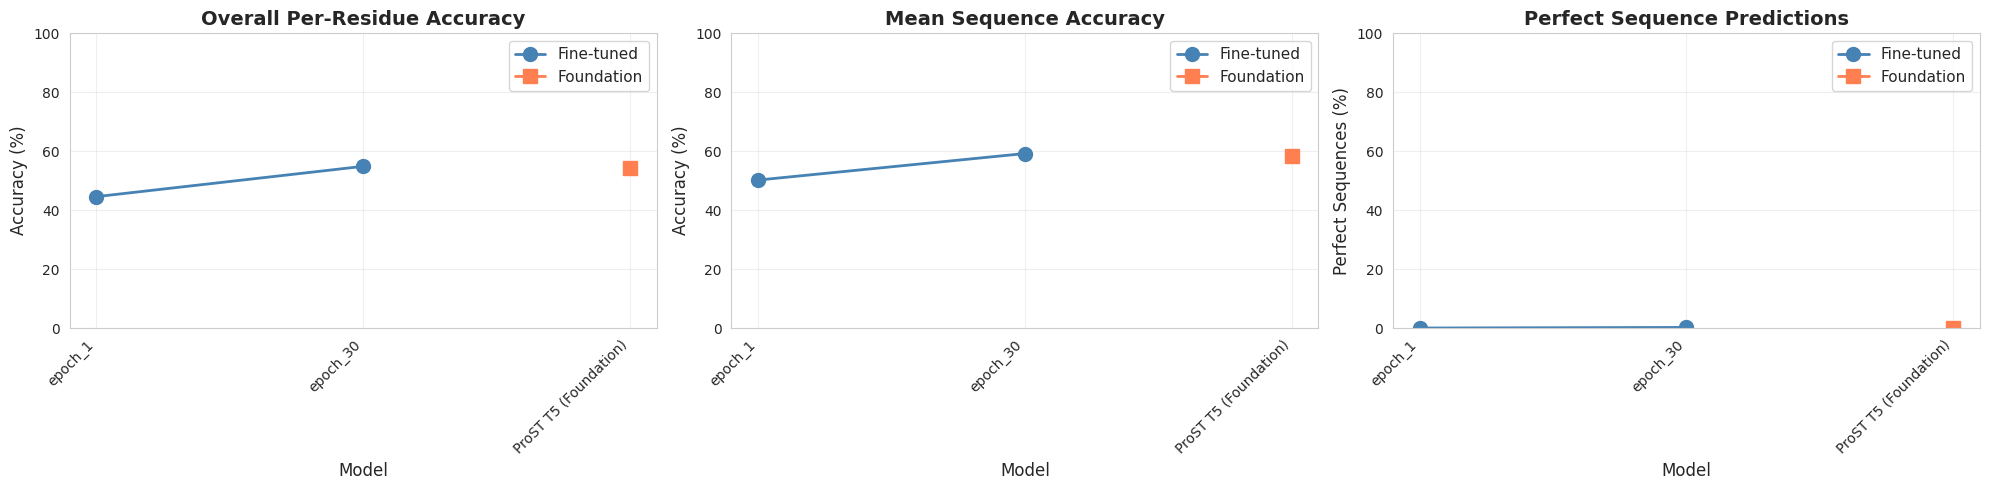

In [36]:
# Plot accuracy metrics across checkpoints and foundation models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Separate fine-tuned and foundation models
finetuned_df = comparison_df[comparison_df['Type'] == 'Fine-tuned'].reset_index(drop=True)
foundation_df = comparison_df[comparison_df['Type'] == 'Foundation'].reset_index(drop=True)

colors_ft = 'steelblue'
colors_foundation = 'coral'

# Overall Accuracy
if len(finetuned_df) > 0:
	axes[0].plot(finetuned_df.index, finetuned_df['Overall Accuracy (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[0].plot(len(finetuned_df) + foundation_df.index, foundation_df['Overall Accuracy (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Overall Per-Residue Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(comparison_df)))
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])
axes[0].legend(fontsize=11)

# Mean Sequence Accuracy
if len(finetuned_df) > 0:
	axes[1].plot(finetuned_df.index, finetuned_df['Mean Sequence Accuracy (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[1].plot(len(finetuned_df) + foundation_df.index, foundation_df['Mean Sequence Accuracy (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Mean Sequence Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(comparison_df)))
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])
axes[1].legend(fontsize=11)

# Perfect Sequences
if len(finetuned_df) > 0:
	axes[2].plot(finetuned_df.index, finetuned_df['Perfect Sequences (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[2].plot(len(finetuned_df) + foundation_df.index, foundation_df['Perfect Sequences (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[2].set_xlabel('Model', fontsize=12)
axes[2].set_ylabel('Perfect Sequences (%)', fontsize=12)
axes[2].set_title('Perfect Sequence Predictions', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(comparison_df)))
axes[2].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 100])
axes[2].legend(fontsize=11)

plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'checkpoint_comparison_with_foundation.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved plot to {plot_path}")
plt.show()


## 10. Per-Sequence Accuracy Distribution

Visualize the distribution of per-sequence accuracies for each checkpoint.

✓ Saved plot to evaluation_results/sequence_accuracy_distributions.png


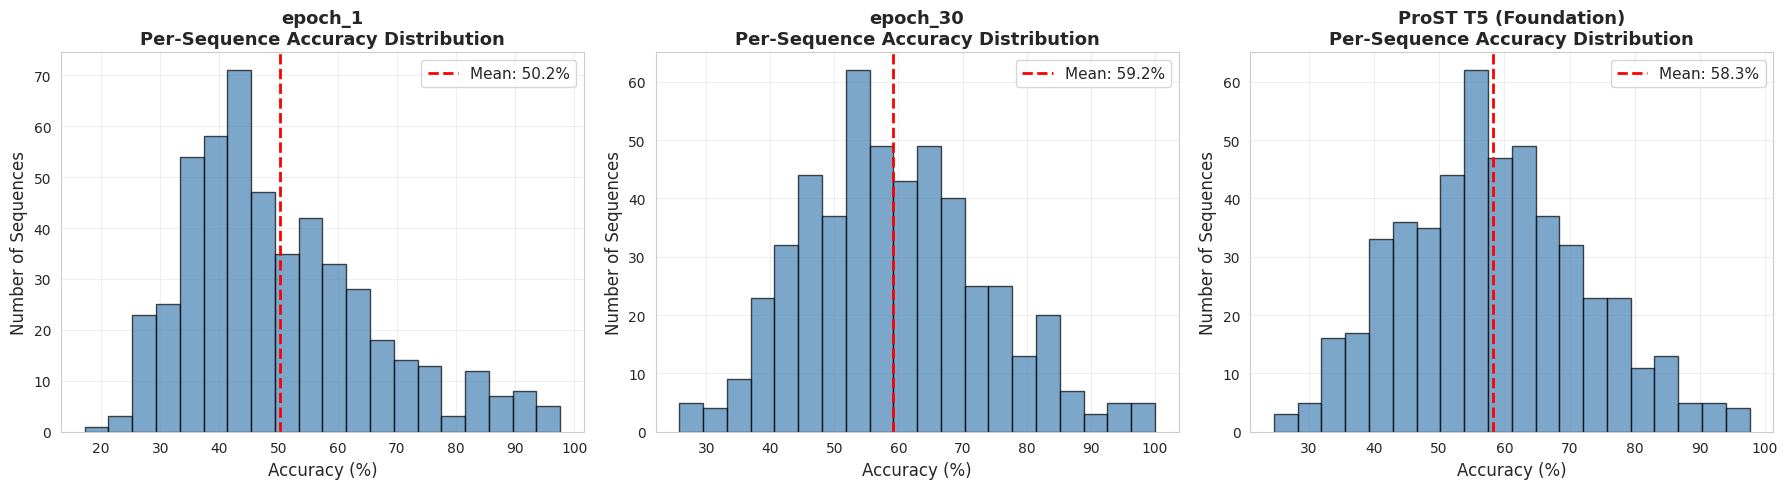

In [37]:
# Plot per-sequence accuracy distributions
fig, axes = plt.subplots(1, len(all_results), figsize=(6*len(all_results), 5))

if len(all_results) == 1:
	axes = [axes]

for idx, result in enumerate(all_results):
	per_seq_acc = np.array(result['metrics']['per_sequence_accuracies']) * 100
	
	axes[idx].hist(per_seq_acc, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
	axes[idx].axvline(per_seq_acc.mean(), color='red', linestyle='--', 
					 linewidth=2, label=f'Mean: {per_seq_acc.mean():.1f}%')
	axes[idx].set_xlabel('Accuracy (%)', fontsize=12)
	axes[idx].set_ylabel('Number of Sequences', fontsize=12)
	axes[idx].set_title(f"{result['checkpoint']}\nPer-Sequence Accuracy Distribution", 
					   fontsize=13, fontweight='bold')
	axes[idx].legend(fontsize=11)
	axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'sequence_accuracy_distributions.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved plot to {plot_path}")
plt.show()

## 11. Confusion Matrix (Best Checkpoint)

Generate a confusion matrix for the best performing checkpoint.

Best checkpoint: epoch_30
Overall accuracy: 54.87%

✓ Saved confusion matrix to evaluation_results/confusion_matrix_epoch_30.png


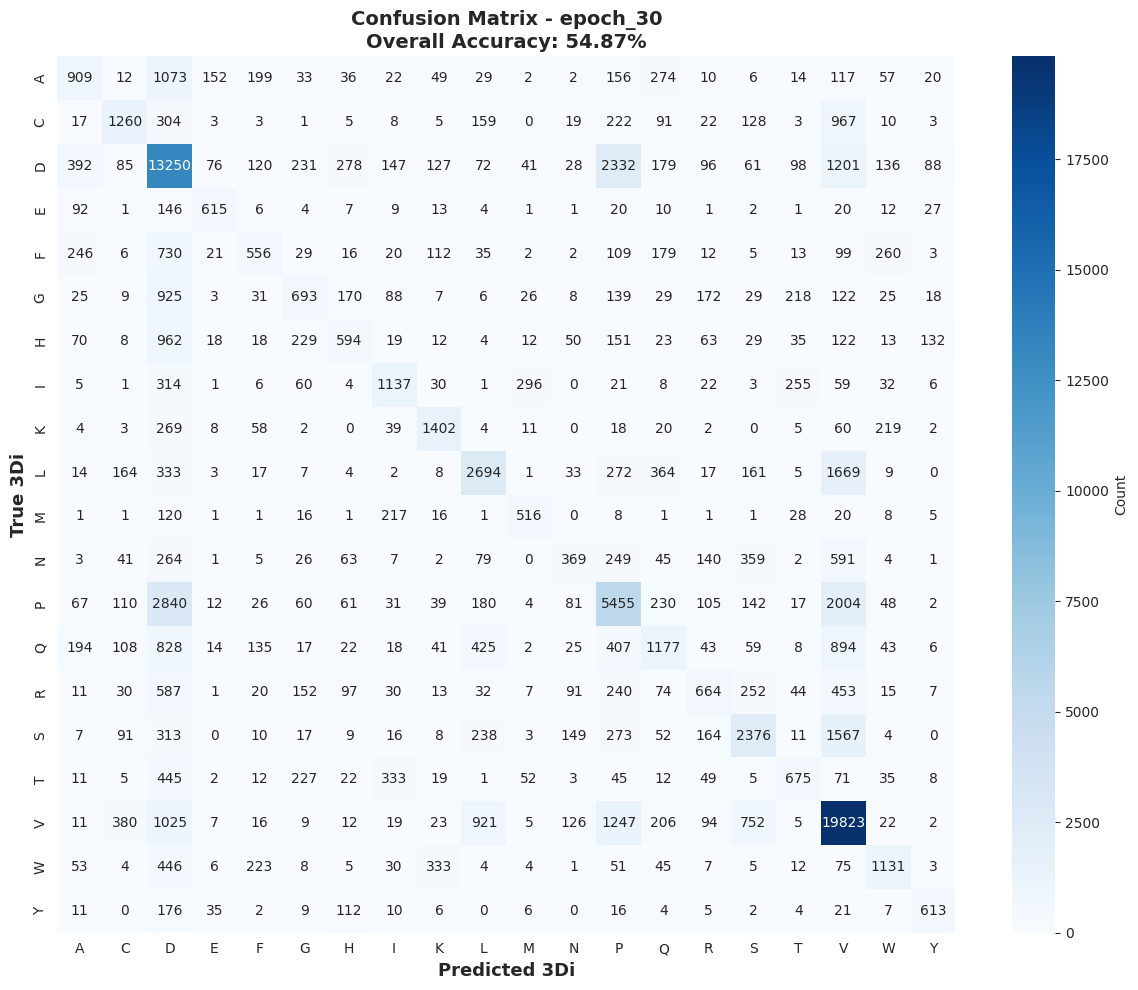

In [38]:
# Find best checkpoint (by overall accuracy)
best_idx = np.argmax([r['metrics']['overall_accuracy'] for r in all_results])
best_result = all_results[best_idx]

print(f"Best checkpoint: {best_result['checkpoint']}")
print(f"Overall accuracy: {best_result['metrics']['overall_accuracy']*100:.2f}%\n")

# Get labels
true_labels = best_result['metrics']['true_labels']
pred_labels = best_result['metrics']['pred_labels']
label_vocab = best_result['label_vocab']

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=label_vocab)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
			xticklabels=label_vocab, yticklabels=label_vocab,
			cbar_kws={'label': 'Count'})
plt.xlabel('Predicted 3Di', fontsize=13, fontweight='bold')
plt.ylabel('True 3Di', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - {best_result["checkpoint"]}\n'
		  f'Overall Accuracy: {best_result["metrics"]["overall_accuracy"]*100:.2f}%',
		  fontsize=14, fontweight='bold')
plt.tight_layout()

plot_path = os.path.join(EVAL_CONFIG['output_dir'], f'confusion_matrix_{best_result["checkpoint"]}.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved confusion matrix to {plot_path}")
plt.show()

In [39]:

# Side-by-side comparison of best fine-tuned vs ProST T5 (if available)
if prost5_result is not None:
	print("="*80)
	print("DETAILED COMPARISON: BEST FINE-TUNED VS PROST T5")
	print("="*80)
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	ft_metrics = best_ft['metrics']
	prost5_metrics = prost5_result['metrics']
	
	# Create comparison table
	comparison_table = pd.DataFrame({
		'Metric': [
			'Overall Accuracy',
			'Mean Sequence Accuracy',
			'Perfect Sequences',
			'Perfect Sequence %',
			'Total Residues',
			'Correct Residues',
		],
		'Fine-tuned': [
			f"{ft_metrics['overall_accuracy']*100:.2f}%",
			f"{ft_metrics['mean_sequence_accuracy']*100:.2f}%",
			f"{ft_metrics['perfect_sequences']}/{len(test_data)}",
			f"{ft_metrics['perfect_sequence_percentage']*100:.2f}%",
			f"{ft_metrics['total_residues']:,}",
			f"{ft_metrics['correct_residues']:,}",
		],
		'ProST T5': [
			f"{prost5_metrics['overall_accuracy']*100:.2f}%",
			f"{prost5_metrics['mean_sequence_accuracy']*100:.2f}%",
			f"{prost5_metrics['perfect_sequences']}/{len(test_data)}",
			f"{prost5_metrics['perfect_sequence_percentage']*100:.2f}%",
			f"{prost5_metrics['total_residues']:,}",
			f"{prost5_metrics['correct_residues']:,}",
		],
		'Difference': [
			f"{(ft_metrics['overall_accuracy']-prost5_metrics['overall_accuracy'])*100:+.2f}%",
			f"{(ft_metrics['mean_sequence_accuracy']-prost5_metrics['mean_sequence_accuracy'])*100:+.2f}%",
			f"{ft_metrics['perfect_sequences']-prost5_metrics['perfect_sequences']:+d}",
			f"{(ft_metrics['perfect_sequence_percentage']-prost5_metrics['perfect_sequence_percentage'])*100:+.2f}%",
			f"{ft_metrics['total_residues']-prost5_metrics['total_residues']:+d}",
			f"{ft_metrics['correct_residues']-prost5_metrics['correct_residues']:+d}",
		]
	})
	
	print(f"\n{best_ft['checkpoint']} (Fine-tuned) vs ProST T5 (Foundation)\n")
	print(comparison_table.to_string(index=False))
	print("\n" + "="*80)
	
	# Save comparison
	comparison_table.to_csv(
		os.path.join(EVAL_CONFIG['output_dir'], 'finetuned_vs_foundation_comparison.csv'),
		index=False
	)


DETAILED COMPARISON: BEST FINE-TUNED VS PROST T5

epoch_30 (Fine-tuned) vs ProST T5 (Foundation)

                Metric Fine-tuned ProST T5 Difference
      Overall Accuracy     54.87%   54.45%     +0.42%
Mean Sequence Accuracy     59.21%   58.31%     +0.90%
     Perfect Sequences      1/500    0/500         +1
    Perfect Sequence %      0.20%    0.00%     +0.20%
        Total Residues    101,902  104,784      -2882
      Correct Residues     55,909   57,052      -1143



## 12. Per-Class Performance (Best Checkpoint)

In [40]:
# Generate classification report
print(f"Classification Report - {best_result['checkpoint']}")
print("=" * 80)

report = classification_report(
	true_labels, pred_labels, 
	labels=label_vocab,
	target_names=label_vocab,
	zero_division=0
)
print(report)

# Save report
report_path = os.path.join(EVAL_CONFIG['output_dir'], 
						  f'classification_report_{best_result["checkpoint"]}.txt')
with open(report_path, 'w') as f:
	f.write(f"Classification Report - {best_result['checkpoint']}\n")
	f.write("=" * 80 + "\n")
	f.write(report)

print(f"\n✓ Saved classification report to {report_path}")

Classification Report - epoch_30
              precision    recall  f1-score   support

           A       0.42      0.29      0.34      3172
           C       0.54      0.39      0.45      3230
           D       0.52      0.70      0.60     19038
           E       0.63      0.62      0.62       992
           F       0.38      0.23      0.28      2455
           G       0.38      0.25      0.30      2743
           H       0.39      0.23      0.29      2564
           I       0.52      0.50      0.51      2261
           K       0.62      0.66      0.64      2126
           L       0.55      0.47      0.51      5777
           M       0.52      0.54      0.53       963
           N       0.37      0.16      0.23      2251
           P       0.48      0.47      0.48     11514
           Q       0.39      0.26      0.31      4466
           R       0.39      0.24      0.29      2820
           S       0.54      0.45      0.49      5308
           T       0.46      0.33      0.39     


Generating confusion matrix comparison...

✓ Saved confusion matrix comparison to evaluation_results/confusion_matrix_comparison.png


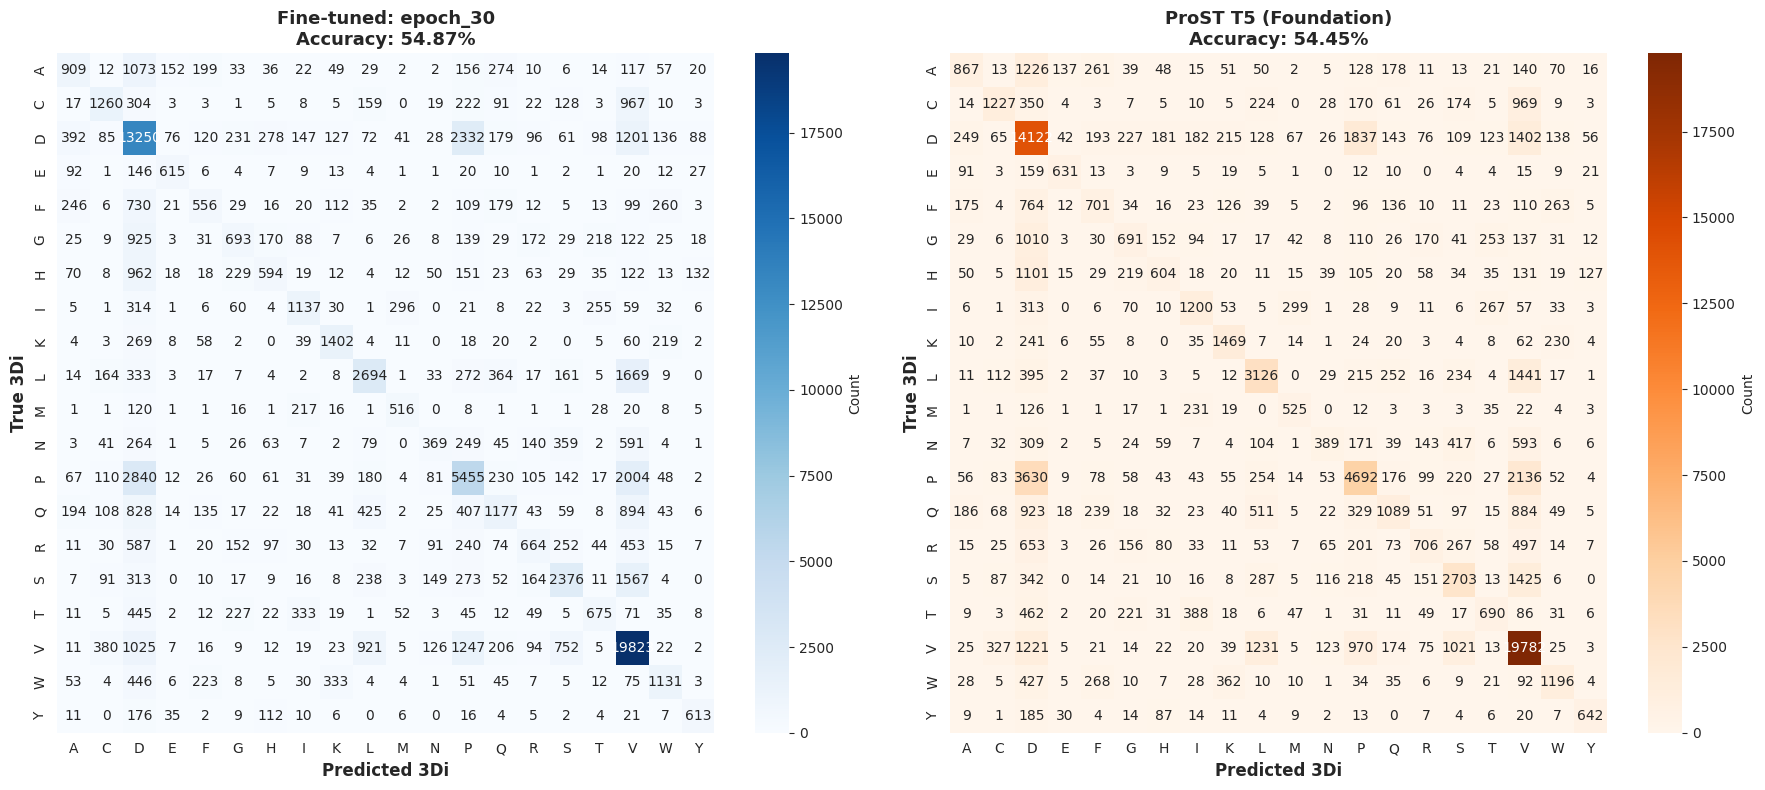

In [41]:

# Comparison confusion matrices
if prost5_result is not None:
	print("\nGenerating confusion matrix comparison...\n")
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	# Get label vocab (union of both models)
	ft_labels = best_ft['metrics']['true_labels']
	prost5_labels = prost5_result['metrics']['true_labels']
	all_labels = sorted(set(ft_labels + prost5_labels + best_ft['label_vocab']))
	
	# Compute confusion matrices
	ft_cm = confusion_matrix(best_ft['metrics']['true_labels'], 
							 best_ft['metrics']['pred_labels'], 
							 labels=all_labels)
	prost5_cm = confusion_matrix(prost5_result['metrics']['true_labels'], 
								 prost5_result['metrics']['pred_labels'], 
								 labels=all_labels)
	
	# Plot side-by-side
	fig, axes = plt.subplots(1, 2, figsize=(18, 8))
	
	sns.heatmap(ft_cm, annot=True, fmt='d', cmap='Blues', 
				xticklabels=all_labels, yticklabels=all_labels,
				cbar_kws={'label': 'Count'}, ax=axes[0])
	axes[0].set_xlabel('Predicted 3Di', fontsize=12, fontweight='bold')
	axes[0].set_ylabel('True 3Di', fontsize=12, fontweight='bold')
	axes[0].set_title(f'Fine-tuned: {best_ft["checkpoint"]}\n'
					  f'Accuracy: {best_ft["metrics"]["overall_accuracy"]*100:.2f}%',
					  fontsize=13, fontweight='bold')
	
	sns.heatmap(prost5_cm, annot=True, fmt='d', cmap='Oranges', 
				xticklabels=all_labels, yticklabels=all_labels,
				cbar_kws={'label': 'Count'}, ax=axes[1])
	axes[1].set_xlabel('Predicted 3Di', fontsize=12, fontweight='bold')
	axes[1].set_ylabel('True 3Di', fontsize=12, fontweight='bold')
	axes[1].set_title(f'ProST T5 (Foundation)\n'
					  f'Accuracy: {prost5_result["metrics"]["overall_accuracy"]*100:.2f}%',
					  fontsize=13, fontweight='bold')
	
	plt.tight_layout()
	plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'confusion_matrix_comparison.png')
	plt.savefig(plot_path, dpi=300, bbox_inches='tight')
	print(f"✓ Saved confusion matrix comparison to {plot_path}")
	plt.show()


## 13. Visualize Example Predictions

Show detailed predictions for a few example sequences.

In [44]:
# Select checkpoint to visualize (use best checkpoint)
selected_result = best_result
predictions = selected_result['predictions']

# Number of examples to show
num_examples = min(5, len(test_data))

print(f"Example Predictions - {selected_result['checkpoint']}")
print("=" * 100)

for i in range(num_examples):
	header = test_data.iloc[i]['header']
	aa_seq = test_data.iloc[i]['aa_sequence']
	true_3di = test_data.iloc[i]['true_3di']
	pred_3di = predictions[i]
	
	# Get ProST T5 prediction if available
	prost5_3di = test_data.iloc[i].get('prost5_3di', None)
	
	# Calculate accuracy for fine-tuned model
	matches = sum(1 for p, t in zip(pred_3di, true_3di) if p == t)
	valid_pos = len(true_3di)
	accuracy = (matches / valid_pos * 100) if valid_pos > 0 else 0.0
	
	# Calculate accuracy for ProST T5 if available
	prost5_accuracy = None
	if prost5_3di is not None:
		prost5_matches = sum(1 for p, t in zip(prost5_3di, true_3di) if p == t)
		prost5_accuracy = (prost5_matches / valid_pos * 100) if valid_pos > 0 else 0.0
	
	print(f"\nExample {i+1}: {header}")
	print(f"Length: {len(aa_seq)} residues | Fine-tuned Accuracy: {accuracy:.2f}%", end="")
	if prost5_accuracy is not None:
		print(f" | ProST T5 Accuracy: {prost5_accuracy:.2f}%")
	else:
		print()
	print("-" * 100)
	
	# Show first 80 characters
	show_len = min(150, len(aa_seq))
	print(f"AA:            {aa_seq[:show_len]}")
	print(f"True 3Di:      {true_3di[:show_len]}")
	print(f"Fine-tuned:    {pred_3di[:show_len]}")
	
	# Show match/mismatch indicators for fine-tuned
	indicators = ''.join(['✓' if p == t else '✗'
						 for p, t in zip(pred_3di[:show_len], true_3di[:show_len])])
	print(f"Match (FT):    {indicators}")
	
	# Show ProST T5 prediction and match indicators if available
	if prost5_3di is not None:
		print(f"ProST T5:      {prost5_3di[:show_len]}")
		prost5_indicators = ''.join(['✓' if p == t else '✗'
									 for p, t in zip(prost5_3di[:show_len], true_3di[:show_len])])
		print(f"Match (ProST): {prost5_indicators}")
	
	if len(aa_seq) > show_len:
		print(f"... (showing first {show_len} of {len(aa_seq)} residues)")

print("\n" + "=" * 100)

Example Predictions - epoch_30

Example 1: imgvr_pc_000105785
Length: 73 residues | Fine-tuned Accuracy: 83.56%
----------------------------------------------------------------------------------------------------
AA:            MSWVSLILLILRIVDAATNWLRDQQGIKAGEDAEIAKASAAILLKTQSAKQIMAEVTAMTDAQVDEALKRLES
True 3Di:      DDPVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVPDDPVVVVVVVVVVVD
Fine-tuned:    DDPVVVLVVLVVLLVVVVVVVVVVVVVDPVVVVVVVVVVVVVVVVVVVSVVSSVVSVVDDPVVVVVSVVVVVD
Match (FT):    ✓✓✓✓✓✓✗✓✓✗✓✓✗✗✓✓✓✓✓✓✓✓✓✓✓✓✓✗✗✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✗✓✓✗✗✓✓✗✓✗✓✓✓✓✓✓✓✓✗✓✓✓✓✓✓

Example 2: imgvr_pc_000662667
Length: 170 residues | Fine-tuned Accuracy: 51.76%
----------------------------------------------------------------------------------------------------
AA:            VKQLKNRKPAIIGLAVVCLFTGYHTFFGKAKTVTNVASLPYTETDRRANQYQIDELKYEKNKADFIEILDYLVSFENMGYFNMKWDIPDKYTVTVSLDIDNAARVHDATAVQVYDIVRANKDSFGYYLQAFNNTFHNGKAKEGDLTLIIT
True 3Di:      DPPPPPCLLVVVVVLLVPLAPPPPPPPDDDDDDDDDDDDDDDPVVVVVVVVVVVVVVVVVLQVVLQV


PER-CLASS ACCURACY COMPARISON

3Di Class  Fine-tuned (%)  ProST T5 (%)  Difference
        A       28.656999     26.344576    2.312423
        C       39.009288     37.249545    1.759743
        D       69.597647     72.120934   -2.523287
        E       61.995968     62.228797   -0.232829
        F       22.647658     27.436399   -4.788741
        G       25.264309     24.001389    1.262920
        H       23.166927     22.749529    0.417397
        I       50.287483     50.462574   -0.175090
        K       65.945437     66.681798   -0.736360
        L       46.633201     52.786221   -6.153020
        M       53.582555     52.083333    1.499221
        N       16.392714     16.738382   -0.345668
        P       47.377106     39.823460    7.553647
        Q       26.354680     23.653345    2.701335
        R       23.546099     23.932203   -0.386104
        S       44.762622     49.396930   -4.634307
        T       33.218504     32.409582    0.808922
        V       80.238818     78

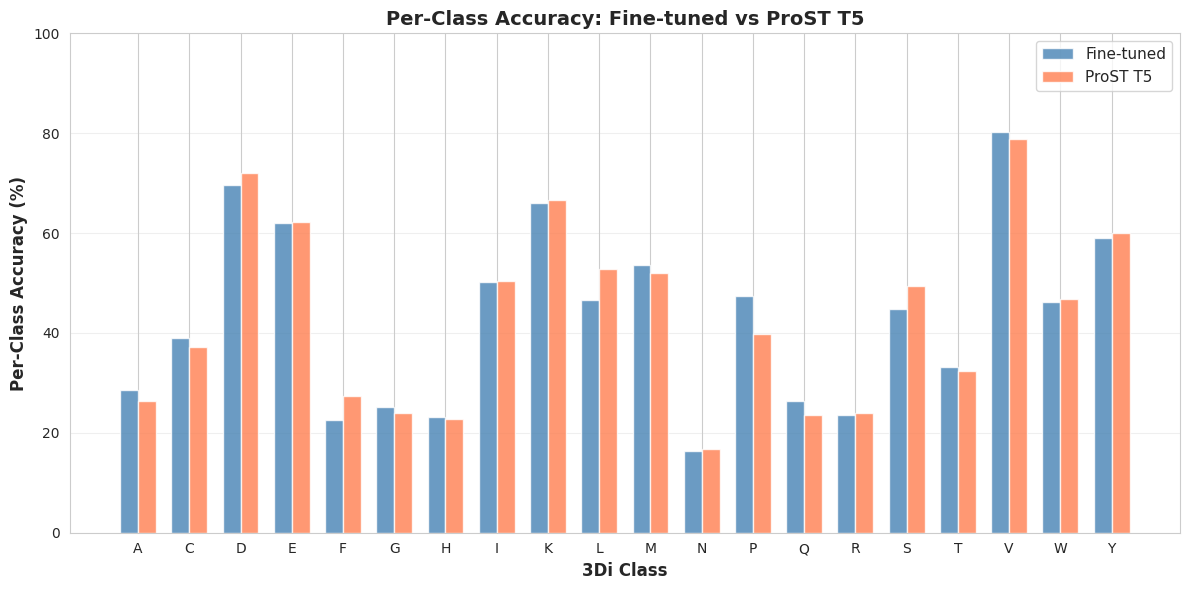

In [45]:

# Per-class accuracy comparison
if prost5_result is not None:
	print("\n" + "="*80)
	print("PER-CLASS ACCURACY COMPARISON")
	print("="*80 + "\n")
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	# Get label vocab
	all_labels = sorted(set(best_ft['label_vocab']))
	
	# Calculate per-class accuracies
	ft_per_class = {}
	prost5_per_class = {}
	
	for label in all_labels:
		# Fine-tuned
		ft_true = [t == label for t in best_ft['metrics']['true_labels']]
		ft_pred = [p == label for p in best_ft['metrics']['pred_labels']]
		ft_tp = sum(t and p for t, p in zip(ft_true, ft_pred))
		ft_total = sum(ft_true)
		ft_per_class[label] = (ft_tp / ft_total * 100) if ft_total > 0 else 0.0
		
		# ProST T5
		prost5_true = [t == label for t in prost5_result['metrics']['true_labels']]
		prost5_pred = [p == label for p in prost5_result['metrics']['pred_labels']]
		prost5_tp = sum(t and p for t, p in zip(prost5_true, prost5_pred))
		prost5_total = sum(prost5_true)
		prost5_per_class[label] = (prost5_tp / prost5_total * 100) if prost5_total > 0 else 0.0
	
	# Create comparison DataFrame
	per_class_df = pd.DataFrame({
		'3Di Class': list(all_labels),
		'Fine-tuned (%)': [ft_per_class[l] for l in all_labels],
		'ProST T5 (%)': [prost5_per_class[l] for l in all_labels],
		'Difference': [ft_per_class[l] - prost5_per_class[l] for l in all_labels],
	})
	
	print(per_class_df.to_string(index=False))
	
	# Plot per-class accuracy
	fig, ax = plt.subplots(figsize=(12, 6))
	
	x = np.arange(len(all_labels))
	width = 0.35
	
	ax.bar(x - width/2, per_class_df['Fine-tuned (%)'], width, 
		   label='Fine-tuned', color='steelblue', alpha=0.8)
	ax.bar(x + width/2, per_class_df['ProST T5 (%)'], width, 
		   label='ProST T5', color='coral', alpha=0.8)
	
	ax.set_xlabel('3Di Class', fontsize=12, fontweight='bold')
	ax.set_ylabel('Per-Class Accuracy (%)', fontsize=12, fontweight='bold')
	ax.set_title('Per-Class Accuracy: Fine-tuned vs ProST T5', fontsize=14, fontweight='bold')
	ax.set_xticks(x)
	ax.set_xticklabels(all_labels)
	ax.legend(fontsize=11)
	ax.grid(True, alpha=0.3, axis='y')
	ax.set_ylim([0, 100])
	
	plt.tight_layout()
	plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'per_class_accuracy_comparison.png')
	plt.savefig(plot_path, dpi=300, bbox_inches='tight')
	print(f"\n✓ Saved per-class comparison to {plot_path}")
	plt.show()
	
	# Save to CSV
	per_class_df.to_csv(
		os.path.join(EVAL_CONFIG['output_dir'], 'per_class_accuracy_comparison.csv'),
		index=False
	)



ACCURACY DISTRIBUTION ACROSS SEQUENCE LENGTHS

✓ Saved accuracy vs sequence length plot to evaluation_results/accuracy_vs_sequence_length.png


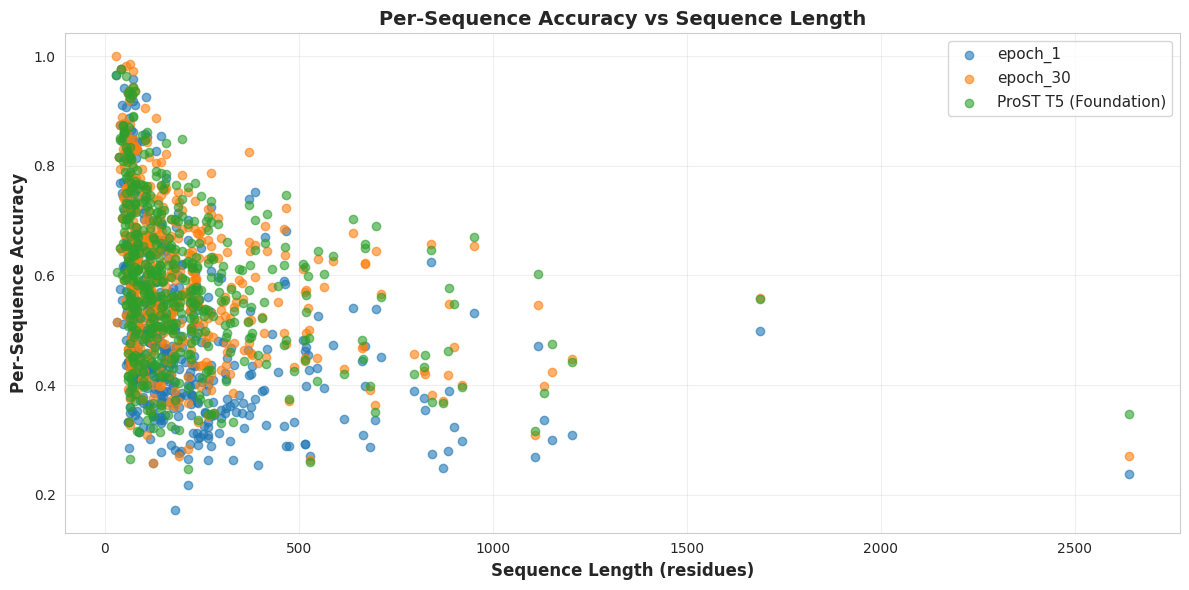


VIOLIN PLOT OF PER-SEQUENCE ACCURACIES



/tmp/ipykernel_662671/4196472893.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Checkpoint', y='Per-Sequence Accuracy', data=violin_df, palette='Set2')


✓ Saved per-sequence accuracy violin plot to evaluation_results/per_sequence_accuracy_violin.png


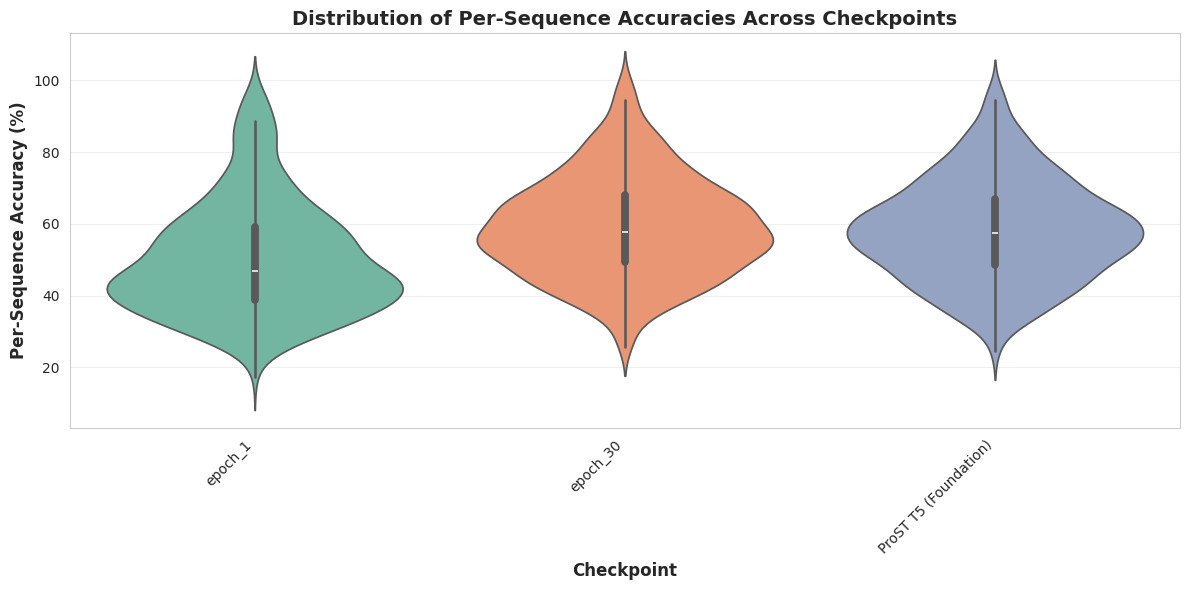

In [72]:
#show the distribution of accuracy across sequence lengths
print("\n" + "="*80)
print("ACCURACY DISTRIBUTION ACROSS SEQUENCE LENGTHS")
print("="*80 + "\n")
# Add sequence lengths to results
for result in all_results:
	seq_lengths = [len(seq) for seq in test_data['aa_sequence']]
	result['seq_lengths'] = seq_lengths
# Plot accuracy vs sequence length
fig, ax = plt.subplots(figsize=(12, 6))
for result in all_results:
	accuracies = result['metrics']['per_sequence_accuracies']
	lengths = result['seq_lengths']
	ax.scatter(lengths, accuracies, alpha=0.6, label=result['checkpoint'])
ax.set_xlabel('Sequence Length (residues)', fontsize=12, fontweight='bold')
ax.set_ylabel('Per-Sequence Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Sequence Accuracy vs Sequence Length', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'accuracy_vs_sequence_length.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved accuracy vs sequence length plot to {plot_path}")
plt.show()

#show violin plot of per-sequence accuracies
print("\n" + "="*80)
print("VIOLIN PLOT OF PER-SEQUENCE ACCURACIES")
print("="*80 + "\n")
# Prepare data for violin plot
violin_data = []
for result in all_results:
	for acc in result['metrics']['per_sequence_accuracies']:
		violin_data.append({
			'Checkpoint': result['checkpoint'],
			'Per-Sequence Accuracy': acc * 100
		})
violin_df = pd.DataFrame(violin_data)
# Plot violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Checkpoint', y='Per-Sequence Accuracy', data=violin_df, palette='Set2')
plt.xlabel('Checkpoint', fontsize=12, fontweight='bold')
plt.ylabel('Per-Sequence Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Per-Sequence Accuracies Across Checkpoints', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'per_sequence_accuracy_violin.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved per-sequence accuracy violin plot to {plot_path}")
plt.show()

## 17. High vs Low Confidence Region Evaluation

Evaluate model performance on high-confidence vs low-confidence regions based on plDDT scores.

In [46]:
# Configuration for plDDT-based masked/unmasked evaluation
MASKING_EVAL_CONFIG = {
    'test_high_confidence': True,     # Test on high-confidence regions
    'test_low_confidence': True,      # Test on low-confidence regions
    'plddt_thresholds': [90, 70, 50, 30],  # plDDT thresholds to test (mask below threshold)
    'mask_token': 'X',  # Token used for masking low-confidence regions
    'plddt_file_pattern': None,  # Pattern for plDDT files, will be auto-detected
    'default_plddt': 80,  # Default plDDT if not available
}

print("plDDT-Based Masking Evaluation Configuration:")
print("=" * 60)
for key, value in MASKING_EVAL_CONFIG.items():
    print(f"  {key}: {value}")
print("=" * 60)

plDDT-Based Masking Evaluation Configuration:
  test_high_confidence: True
  test_low_confidence: True
  plddt_thresholds: [90, 70, 50, 30]
  mask_token: X
  plddt_file_pattern: None
  default_plddt: 80


In [47]:
def load_plddt_scores(sequence_headers: List[str], plddt_file_pattern: str = None) -> Dict[str, List[float]]:
    """
    Load plDDT scores for sequences from files. Tries multiple common patterns.
    
    Args:
        sequence_headers: List of sequence headers/IDs from FASTA
        plddt_file_pattern: Optional specific pattern for plDDT files (with {} for seq_id)
        
    Returns:
        Dictionary mapping sequence IDs to lists of plDDT scores
    """
    plddt_data = {}
    
    # Common plDDT file patterns to try
    patterns_to_try = [
        plddt_file_pattern,
        "plddt_{}.txt",
        "{}_plddt.txt", 
        "confidence_{}.txt",
        "{}_confidence.txt",
        "scores_{}.txt",
        "{}.plddt",
        "plddt_{}.json"
    ]
    
    found_files = 0
    
    for header in sequence_headers:
        # Clean header to extract sequence ID (remove '>', split on whitespace/pipes)
        seq_id = header.replace('>', '').split()[0].split('|')[0]
        
        plddt_scores = None
        
        # Try each pattern to find plDDT file
        for pattern in patterns_to_try:
            if pattern is None:
                continue
                
            try:
                plddt_file = pattern.format(seq_id)
                if os.path.exists(plddt_file):
                    # Try different file formats
                    if plddt_file.endswith('.json'):
                        import json
                        with open(plddt_file, 'r') as f:
                            data = json.load(f)
                            plddt_scores = data.get('plddt', data.get('confidence', []))
                    else:
                        # Assume text file with one score per line
                        with open(plddt_file, 'r') as f:
                            scores = []
                            for line in f:
                                line = line.strip()
                                if line and not line.startswith('#'):
                                    try:
                                        scores.append(float(line))
                                    except ValueError:
                                        continue
                            plddt_scores = scores if scores else None
                    
                    if plddt_scores:
                        found_files += 1
                        break
                        
            except Exception as e:
                print(f"⚠️ Error reading plDDT file for {seq_id}: {e}")
                continue
        
        # Use default scores if no plDDT file found
        if plddt_scores is None:
            print(f"ℹ️ No plDDT file found for {seq_id}, using default confidence")
            plddt_scores = [MASKING_EVAL_CONFIG['default_plddt']]
        
        plddt_data[seq_id] = plddt_scores
    
    print(f"✓ Loaded plDDT data for {len(plddt_data)} sequences ({found_files} from files)")
    return plddt_data


def create_plddt_masked_data(sequences: List[str], headers: List[str], 
                            plddt_threshold: float = 70, mask_token: str = 'X',
                            plddt_data: Dict[str, List[float]] = None) -> List[str]:
    """
    Create masked versions of 3Di sequences by masking low-confidence positions.
    
    Args:
        sequences: List of 3Di sequences to potentially mask
        headers: Corresponding sequence headers/IDs
        plddt_threshold: plDDT threshold below which positions are masked
        mask_token: Token to use for masking low-confidence positions
        plddt_data: Pre-loaded plDDT scores (if None, will load automatically)
        
    Returns:
        List of masked sequences (high-confidence positions preserved)
    """
    if plddt_data is None:
        plddt_data = load_plddt_scores(headers)
    
    masked_sequences = []
    total_tokens = 0
    total_masked = 0
    sequences_with_plddt = 0
    
    for seq, header in zip(sequences, headers):
        # Extract sequence ID from header
        seq_id = header.replace('>', '').split()[0].split('|')[0]
        
        if seq_id in plddt_data and plddt_data[seq_id]:
            plddt_scores = plddt_data[seq_id].copy()
            
            # Handle length mismatches between sequence and plDDT scores
            if len(plddt_scores) < len(seq):
                # Extend with last score or default
                extend_score = plddt_scores[-1] if plddt_scores else MASKING_EVAL_CONFIG['default_plddt']
                plddt_scores.extend([extend_score] * (len(seq) - len(plddt_scores)))
            elif len(plddt_scores) > len(seq):
                # Truncate to sequence length
                plddt_scores = plddt_scores[:len(seq)]
            
            # Create masked sequence
            masked_seq = []
            for residue, plddt_score in zip(seq, plddt_scores):
                if plddt_score < plddt_threshold:
                    masked_seq.append(mask_token)
                    total_masked += 1
                else:
                    masked_seq.append(residue)
                total_tokens += 1
            
            masked_sequences.append(''.join(masked_seq))
            sequences_with_plddt += 1
            
        else:
            # No plDDT data available - keep sequence unchanged
            masked_sequences.append(seq)
            total_tokens += len(seq)
    
    # Report masking statistics
    mask_ratio = total_masked / total_tokens if total_tokens > 0 else 0.0
    print(f"✓ Created plDDT-masked data (threshold < {plddt_threshold}):")
    print(f"  {total_masked:,}/{total_tokens:,} positions masked ({mask_ratio:.1%})")
    print(f"  {sequences_with_plddt}/{len(sequences)} sequences had plDDT data")
    
    return masked_sequences


def evaluate_on_data_type(model, tokenizer, label_vocab, test_aa_sequences: List[str], 
                         true_3di_sequences: List[str], data_type_name: str,
                         device: str, batch_size: int = 8) -> Dict:
    """
    Evaluate model performance on a specific data type (e.g., high/low confidence regions).
    
    Args:
        model: Trained ESM3Di model
        tokenizer: Model tokenizer
        label_vocab: 3Di label vocabulary
        test_aa_sequences: Amino acid sequences for input
        true_3di_sequences: Ground truth 3Di sequences
        data_type_name: Descriptive name for this evaluation
        device: Device to run evaluation on
        batch_size: Batch size for inference
        
    Returns:
        Dictionary with evaluation results and metrics
    """
    print(f"\n{'='*70}")
    print(f"EVALUATING ON {data_type_name.upper()}")
    print(f"{'='*70}")
    
    # Report test set statistics
    num_sequences = len(test_aa_sequences)
    total_residues = sum(len(seq) for seq in test_aa_sequences)
    print(f"Test sequences: {num_sequences:,}")
    print(f"Total residues: {total_residues:,}")
    
    # Run model predictions
    print("\n🔮 Running model predictions...")
    predictions = predict_3di_batch(
        model, tokenizer, label_vocab, test_aa_sequences,
        device=device, batch_size=batch_size
    )
    print(f"✓ Generated {len(predictions)} predictions")
    
    # Calculate accuracy metrics
    print("\n📊 Calculating accuracy metrics...")
    metrics = calculate_accuracy(predictions, true_3di_sequences)
    
    # Display results summary
    print(f"\n{'='*50}")
    print(f"{data_type_name.upper()} RESULTS")
    print(f"{'='*50}")
    print(f"Overall Accuracy (per-residue):  {metrics['overall_accuracy']*100:.2f}%")
    print(f"Mean Sequence Accuracy:          {metrics['mean_sequence_accuracy']*100:.2f}%")
    print(f"Perfect Sequences:               {metrics['perfect_sequences']}/{num_sequences} "
          f"({metrics['perfect_sequence_percentage']*100:.2f}%)")
    print(f"Total Residues Evaluated:        {metrics['total_residues']:,}")
    print(f"Correct Predictions:             {metrics['correct_residues']:,}")
    print(f"{'='*50}")
    
    return {
        'data_type': data_type_name,
        'predictions': predictions,
        'metrics': metrics,
        'num_sequences': num_sequences,
        'total_residues': total_residues,
    }

print("✓ plDDT evaluation functions defined")

✓ plDDT evaluation functions defined


## 18. Foundation Model on High vs Low Confidence Regions

Compare foundation model (ProST T5) performance on high-confidence vs low-confidence regions.

In [52]:
# Export detailed predictions for best checkpoint
predictions_df = test_data.copy()
predictions_df['predicted_3di'] = best_result['predictions']

# Calculate per-sequence accuracy
def calc_seq_accuracy(row):
	pred = row['predicted_3di']
	true = row['true_3di']
	matches = sum(1 for p, t in zip(pred, true) if p == t)
	valid = len(true)
	return (matches / valid * 100) if valid > 0 else 0.0

predictions_df['accuracy_%'] = predictions_df.apply(calc_seq_accuracy, axis=1)

# Save to CSV
predictions_csv = os.path.join(EVAL_CONFIG['output_dir'], 
							  f'predictions_{best_result["checkpoint"]}.csv')
predictions_df.to_csv(predictions_csv, index=False)
print(f"✓ Saved detailed predictions to {predictions_csv}")

# Save summary statistics
summary = {
	'checkpoint': best_result['checkpoint'],
	'checkpoint_path': best_result['checkpoint_path'],
	'test_sequences': len(test_data),
	'overall_accuracy': best_result['metrics']['overall_accuracy'],
	'mean_sequence_accuracy': best_result['metrics']['mean_sequence_accuracy'],
	'perfect_sequences': best_result['metrics']['perfect_sequences'],
	'perfect_sequence_percentage': best_result['metrics']['perfect_sequence_percentage'],
	'total_residues': best_result['metrics']['total_residues'],
	'correct_residues': best_result['metrics']['correct_residues'],
	'label_vocabulary': best_result['label_vocab'],
}

summary_json = os.path.join(EVAL_CONFIG['output_dir'], 'evaluation_summary.json')
with open(summary_json, 'w') as f:
	json.dump(summary, f, indent=2)
print(f"✓ Saved summary to {summary_json}")

print(f"\n{'='*80}")
print("All evaluation results exported successfully!")
print(f"{'='*80}")
print(f"\nResults directory: {EVAL_CONFIG['output_dir']}")
print("\nGenerated files:")
for file in sorted(Path(EVAL_CONFIG['output_dir']).glob('*')):
	print(f"  - {file.name}")

✓ Saved detailed predictions to evaluation_results/predictions_epoch_30.csv
✓ Saved summary to evaluation_results/evaluation_summary.json

All evaluation results exported successfully!

Results directory: evaluation_results

Generated files:
  - checkpoint_comparison.csv
  - checkpoint_comparison_with_foundation.png
  - classification_report_ProST T5 (Foundation).txt
  - classification_report_epoch_1.txt
  - classification_report_epoch_2.txt
  - classification_report_epoch_3.txt
  - classification_report_epoch_30.txt
  - confidence_regions_comparison.csv
  - confidence_regions_comparison.png
  - confusion_matrix_ProST T5 (Foundation).png
  - confusion_matrix_comparison.png
  - confusion_matrix_epoch_1.png
  - confusion_matrix_epoch_2.png
  - confusion_matrix_epoch_3.png
  - confusion_matrix_epoch_30.png
  - evaluation_summary.json
  - finetuned_vs_foundation_comparison.csv
  - per_class_accuracy_comparison.csv
  - per_class_accuracy_comparison.png
  - predictions_epoch_1.csv
  - predic

## 16. Summary and Recommendations

Based on the evaluation results, here are some insights and next steps.

In [53]:
print("="*80)
print("EVALUATION SUMMARY")
print("="*80)

# Separate fine-tuned and foundation models
ft_results = [r for r in all_results if not r.get('is_foundation', False)]
foundation_results = [r for r in all_results if r.get('is_foundation', False)]

if ft_results:
	best_ft = max(ft_results, key=lambda x: x['metrics']['overall_accuracy'])
	best_ft_acc = best_ft['metrics']['overall_accuracy'] * 100
	print(f"\n📊 FINE-TUNED MODELS ({len(ft_results)} checkpoints)")
	print("-" * 80)
	print(f"Best Checkpoint: {best_ft['checkpoint']}")
	print(f"Overall Accuracy: {best_ft_acc:.2f}%")
	print(f"\nAll fine-tuned checkpoints:")
	for result in ft_results:
		acc = result['metrics']['overall_accuracy'] * 100
		status = "⭐ BEST" if result == best_ft else ""
		print(f"  {result['checkpoint']}: {acc:.2f}% {status}")

if foundation_results:
	print(f"\n🏛️  FOUNDATION MODELS ({len(foundation_results)} models)")
	print("-" * 80)
	for result in foundation_results:
		acc = result['metrics']['overall_accuracy'] * 100
		print(f"  {result['checkpoint']}: {acc:.2f}%")

# Comparison insights
if ft_results and foundation_results:
	best_ft_acc = best_ft['metrics']['overall_accuracy'] * 100
	prost5_acc = foundation_results[0]['metrics']['overall_accuracy'] * 100
	improvement = best_ft_acc - prost5_acc
	
	print(f"\n📈 COMPARISON INSIGHTS")
	print("-" * 80)
	print(f"Best Fine-tuned:  {best_ft['checkpoint']} ({best_ft_acc:.2f}%)")
	print(f"Foundation Model: {foundation_results[0]['checkpoint']} ({prost5_acc:.2f}%)")
	
	if improvement > 0:
		print(f"\n✓ Fine-tuning provides {improvement:.2f}% improvement over foundation model")
		if improvement > 10:
			print("  → Significant improvement! Fine-tuning is well-justified.")
		elif improvement > 5:
			print("  → Moderate improvement from fine-tuning.")
		else:
			print("  → Modest improvement. Consider foundation model trade-offs.")
	elif improvement < 0:
		print(f"\n⚠ Foundation model outperforms fine-tuned by {abs(improvement):.2f}%")
		print("  → Consider using foundation model or investigating fine-tuning issues.")
	else:
		print("\n• Models have comparable performance")

print(f"\n{'='*80}")
print("RECOMMENDATIONS")
print("="*80)

if ft_results and foundation_results:
	best_overall_acc = max(
		[r['metrics']['overall_accuracy'] for r in ft_results + foundation_results]
	) * 100
else:
	best_overall_acc = max([r['metrics']['overall_accuracy'] for r in all_results]) * 100 if all_results else 0

if best_overall_acc < 70:
	print("\n📊 Model Performance: NEEDS IMPROVEMENT")
	print("\nSuggestions:")
	print("  1. Increase training data size or diversity")
	print("  2. Train for more epochs")
	print("  3. Try a larger ESM model")
	print("  4. Adjust LoRA hyperparameters (increase rank)")
	print("  5. Consider ensemble of fine-tuned + foundation models")
elif best_overall_acc < 85:
	print("\n📊 Model Performance: MODERATE")
	print("\nSuggestions:")
	print("  1. Continue training for more epochs")
	print("  2. Add more diverse training sequences")
	print("  3. Explore data augmentation strategies")
	print("  4. Consider ensemble of multiple fine-tuned checkpoints")
	if foundation_results and foundation_results[0]['metrics']['overall_accuracy'] * 100 > 60:
		print("  5. Ensemble with foundation model for improved robustness")
else:
	print("\n📊 Model Performance: EXCELLENT")
	print("\nNext Steps:")
	print("  1. Test on external/independent datasets")
	print("  2. Deploy model for production use")
	print("  3. Create FoldSeek database with trained model")
	if foundation_results:
		print("  4. Consider ensemble for additional robustness")
	print("  5. Consider publishing or sharing results")

print(f"\n{'='*80}")
print("\n✓ Evaluation complete! Check the output directory for all results and plots.")
print(f"  Output directory: {EVAL_CONFIG['output_dir']}")
print(f"\nGenerated files:")
for file in sorted(Path(EVAL_CONFIG['output_dir']).glob('*')):
	print(f"  - {file.name}")


EVALUATION SUMMARY

📊 FINE-TUNED MODELS (2 checkpoints)
--------------------------------------------------------------------------------
Best Checkpoint: epoch_30
Overall Accuracy: 54.87%

All fine-tuned checkpoints:
  epoch_1: 44.58% 
  epoch_30: 54.87% ⭐ BEST

🏛️  FOUNDATION MODELS (1 models)
--------------------------------------------------------------------------------
  ProST T5 (Foundation): 54.45%

📈 COMPARISON INSIGHTS
--------------------------------------------------------------------------------
Best Fine-tuned:  epoch_30 (54.87%)
Foundation Model: ProST T5 (Foundation) (54.45%)

✓ Fine-tuning provides 0.42% improvement over foundation model
  → Modest improvement. Consider foundation model trade-offs.

RECOMMENDATIONS

📊 Model Performance: NEEDS IMPROVEMENT

Suggestions:
  1. Increase training data size or diversity
  2. Train for more epochs
  3. Try a larger ESM model
  4. Adjust LoRA hyperparameters (increase rank)
  5. Consider ensemble of fine-tuned + foundation model

## 17. pLDDT Distribution Analysis for Taxon-Specific Datasets

Analyze the pLDDT (predicted Local Distance Difference Test) score distributions across the top 10 viral class datasets. pLDDT scores indicate model confidence in structural predictions, with higher values indicating better predicted accuracy.

In [54]:
# Define paths to taxon-specific datasets
TAXON_DATASETS = {
    "Caudoviricetes": "/mnt/data1/bfvd/classes/caudoviricetes",
    "Megaviricetes": "/mnt/data1/bfvd/classes/megaviricetes",
    "Herviviricetes": "/mnt/data1/bfvd/classes/herviviricetes",
    "Naldaviricetes": "/mnt/data1/bfvd/classes/naldaviricetes",
    "Pokkesviricetes": "/mnt/data1/bfvd/classes/pokkesviricetes",
    "Pisoniviricetes": "/mnt/data1/bfvd/classes/pisoniviricetes",
    "Malgrandaviricetes": "/mnt/data1/bfvd/classes/malgrandaviricetes",
    "Revtraviricetes": "/mnt/data1/bfvd/classes/revtraviricetes",
    "Alsuviricetes": "/mnt/data1/bfvd/classes/alsuviricetes",
    "Monjiviricetes": "/mnt/data1/bfvd/classes/monjiviricetes",
}

def read_plddt_bins_fasta(fasta_path: str) -> Dict[str, str]:
    """Read pLDDT bins FASTA file (0-9 per position)."""
    sequences = {}
    current_header = None
    current_seq = []
    
    with open(fasta_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_header is not None:
                    sequences[current_header] = ''.join(current_seq)
                current_header = line[1:]
                current_seq = []
            else:
                current_seq.append(line)
        if current_header is not None:
            sequences[current_header] = ''.join(current_seq)
    
    return sequences


def compute_plddt_distribution(plddt_sequences: Dict[str, str]) -> np.ndarray:
    """Compute histogram of pLDDT bins across all residues."""
    bin_counts = np.zeros(10, dtype=np.int64)
    
    for seq in plddt_sequences.values():
        for char in seq:
            if char.isdigit():
                bin_counts[int(char)] += 1
    
    return bin_counts


# Load and analyze pLDDT distributions for each dataset
print("="*80)
print("pLDDT DISTRIBUTION ANALYSIS FOR TAXON-SPECIFIC DATASETS")
print("="*80)

plddt_distributions = {}

for taxon_name, base_path in TAXON_DATASETS.items():
    plddt_fasta = os.path.join(base_path, f"{base_path.split('/')[-1]}_test_plddt_bins.fasta")
    
    if not os.path.exists(plddt_fasta):
        print(f"⚠ {taxon_name}: pLDDT bins file not found at {plddt_fasta}")
        continue
    
    plddt_seqs = read_plddt_bins_fasta(plddt_fasta)
    counts = compute_plddt_distribution(plddt_seqs)
    total = counts.sum()
    
    plddt_distributions[taxon_name] = {
        'counts': counts,
        'percentages': counts / total * 100,
        'total_residues': total,
        'num_sequences': len(plddt_seqs),
        'mean_plddt_bin': np.average(np.arange(10), weights=counts)
    }
    
    print(f"\n{taxon_name}:")
    print(f"  Sequences: {len(plddt_seqs):,}")
    print(f"  Residues: {total:,}")
    print(f"  Mean pLDDT bin: {plddt_distributions[taxon_name]['mean_plddt_bin']:.2f}")
    print(f"  High confidence (bins 7-9): {counts[7:].sum()/total*100:.1f}%")
    print(f"  Low confidence (bins 0-3): {counts[:4].sum()/total*100:.1f}%")

print(f"\n✓ Loaded pLDDT distributions for {len(plddt_distributions)} datasets")

pLDDT DISTRIBUTION ANALYSIS FOR TAXON-SPECIFIC DATASETS

Caudoviricetes:
  Sequences: 21,076
  Residues: 3,232,788
  Mean pLDDT bin: 6.75
  High confidence (bins 7-9): 61.3%
  Low confidence (bins 0-3): 11.9%

Megaviricetes:
  Sequences: 3,487
  Residues: 820,836
  Mean pLDDT bin: 6.29
  High confidence (bins 7-9): 53.4%
  Low confidence (bins 0-3): 19.1%

Herviviricetes:
  Sequences: 787
  Residues: 197,391
  Mean pLDDT bin: 5.30
  High confidence (bins 7-9): 34.4%
  Low confidence (bins 0-3): 29.6%

Naldaviricetes:
  Sequences: 664
  Residues: 144,945
  Mean pLDDT bin: 5.61
  High confidence (bins 7-9): 40.9%
  Low confidence (bins 0-3): 26.5%

Pokkesviricetes:
  Sequences: 540
  Residues: 108,661
  Mean pLDDT bin: 5.95
  High confidence (bins 7-9): 47.2%
  Low confidence (bins 0-3): 22.8%

Pisoniviricetes:
  Sequences: 506
  Residues: 209,893
  Mean pLDDT bin: 5.81
  High confidence (bins 7-9): 47.9%
  Low confidence (bins 0-3): 27.0%

Malgrandaviricetes:
  Sequences: 453
  Residues

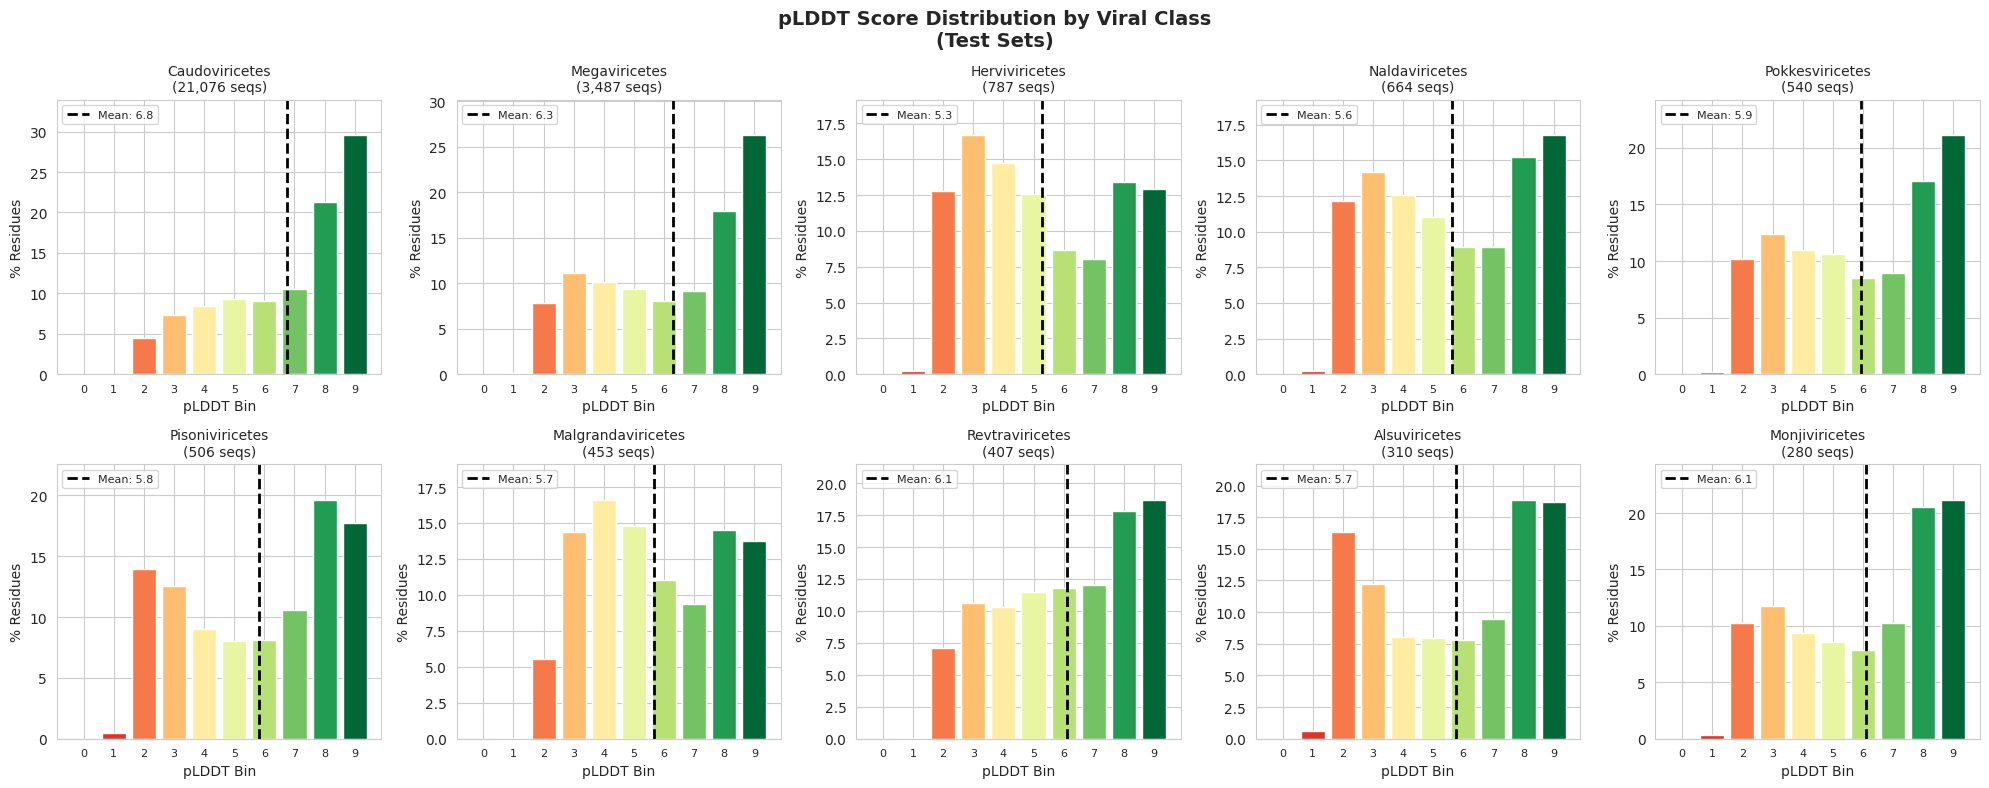

✓ Saved pLDDT distribution plot


In [55]:
# Plot pLDDT distributions for all taxon datasets
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

plddt_labels = [f"{i*10}-{(i+1)*10}" for i in range(10)]
plddt_labels[-1] = "90-100"
colors = plt.cm.RdYlGn(np.linspace(0, 1, 10))  # Red to green colormap

for idx, (taxon_name, data) in enumerate(plddt_distributions.items()):
    ax = axes[idx]
    bars = ax.bar(np.arange(10), data['percentages'], color=colors)
    ax.set_title(f"{taxon_name}\n({data['num_sequences']:,} seqs)", fontsize=10)
    ax.set_xlabel("pLDDT Bin")
    ax.set_ylabel("% Residues")
    ax.set_xticks(np.arange(10))
    ax.set_xticklabels([str(i) for i in range(10)], fontsize=8)
    ax.set_ylim(0, max(data['percentages']) * 1.15)
    
    # Add mean line
    ax.axvline(x=data['mean_plddt_bin'], color='black', linestyle='--', 
               linewidth=2, label=f"Mean: {data['mean_plddt_bin']:.1f}")
    ax.legend(loc='upper left', fontsize=8)

# Hide unused subplots
for idx in range(len(plddt_distributions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("pLDDT Score Distribution by Viral Class\n(Test Sets)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_CONFIG['output_dir'], "plddt_distributions_by_taxon.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved pLDDT distribution plot")

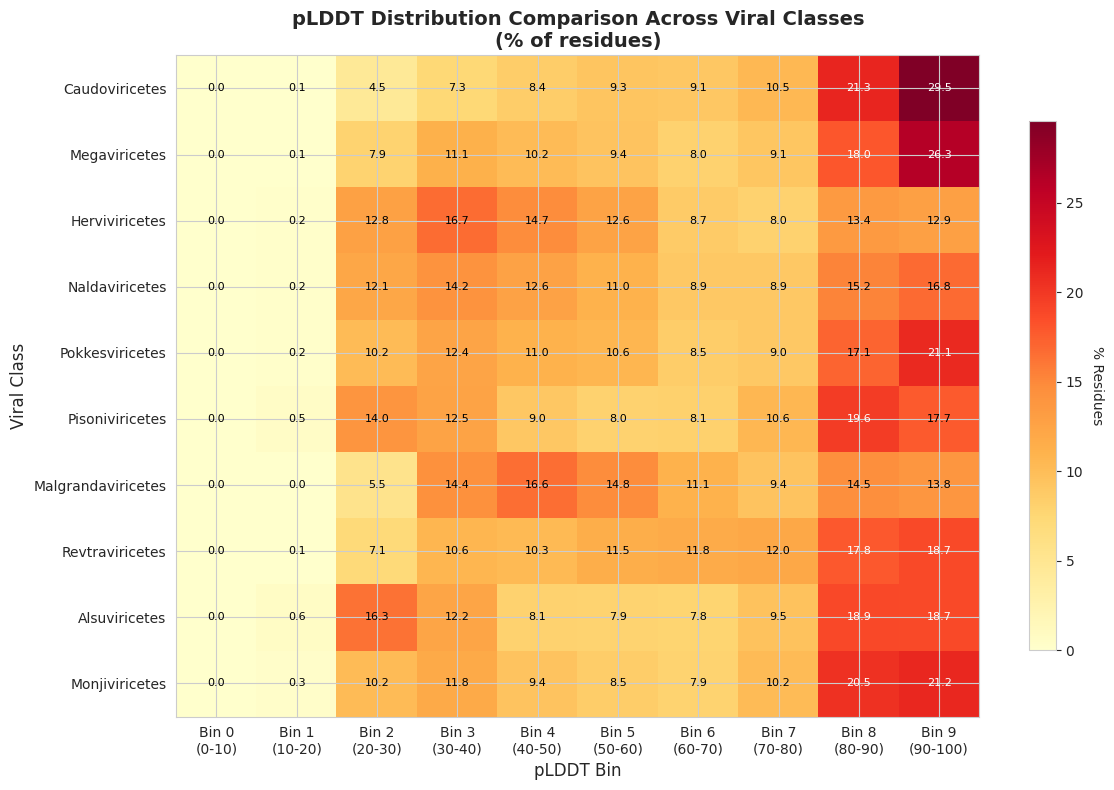

✓ Saved pLDDT heatmap comparison


In [56]:
# Create comparative heatmap of pLDDT distributions
plddt_matrix = np.array([data['percentages'] for data in plddt_distributions.values()])
taxon_names = list(plddt_distributions.keys())

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(plddt_matrix, cmap='YlOrRd', aspect='auto')

# Set labels
ax.set_xticks(np.arange(10))
ax.set_xticklabels([f"Bin {i}\n({i*10}-{min((i+1)*10, 100)})" for i in range(10)])
ax.set_yticks(np.arange(len(taxon_names)))
ax.set_yticklabels(taxon_names)
ax.set_xlabel("pLDDT Bin", fontsize=12)
ax.set_ylabel("Viral Class", fontsize=12)
ax.set_title("pLDDT Distribution Comparison Across Viral Classes\n(% of residues)", fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% Residues", rotation=270, labelpad=15)

# Add text annotations
for i in range(len(taxon_names)):
    for j in range(10):
        value = plddt_matrix[i, j]
        text_color = 'white' if value > plddt_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f"{value:.1f}", ha='center', va='center', color=text_color, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_CONFIG['output_dir'], "plddt_heatmap_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved pLDDT heatmap comparison")

## 18. Per-Class Accuracy by pLDDT Bin

Analyze how model prediction accuracy varies with structural confidence (pLDDT) for each 3Di class. This reveals whether the model performs better on high-confidence regions and identifies potential areas for improvement.

In [58]:
def evaluate_accuracy_by_plddt_bin(
    model_wrapper,
    aa_seqs: Dict[str, str],
    three_di_seqs: Dict[str, str],
    plddt_seqs: Dict[str, str],
    label_vocab: Dict[str, int],
    device: str = "cuda",
    batch_size: int = 4,
    max_sequences: int = 500,
    model_checkpoint_path: Optional[str] = None,
    output_dir: str = "evaluation_results",
 ) -> Dict:
    """
    Evaluate model and compute accuracy by pLDDT bin and 3Di class.
    
    Returns:
        Dictionary with accuracy matrices and statistics
    """
    if isinstance(label_vocab, dict):
        label_to_idx = dict(label_vocab)
    else:
        label_to_idx = {c: i for i, c in enumerate(label_vocab)}
    num_classes = len(label_to_idx)
    
    correct_by_bin_class = np.zeros((10, num_classes), dtype=np.int64)
    total_by_bin_class = np.zeros((10, num_classes), dtype=np.int64)
    
    common_ids = list(set(aa_seqs.keys()) & set(three_di_seqs.keys()) & set(plddt_seqs.keys()))
    if max_sequences and len(common_ids) > max_sequences:
        np.random.seed(42)
        common_ids = list(np.random.choice(common_ids, max_sequences, replace=False))
    
    aa_list = [aa_seqs[seq_id] for seq_id in common_ids]
    predictions = predict_sequences_with_model(
        model_wrapper,
        aa_list,
        output_dir=output_dir,
        model_checkpoint_path=model_checkpoint_path,
        batch_size=batch_size,
        device=device,
    )
    pred_map = dict(zip(common_ids, predictions))
    
    for seq_id in tqdm(common_ids, desc="Evaluating"):
        aa_seq = aa_seqs[seq_id]
        target_3di = three_di_seqs[seq_id]
        plddt_bins = plddt_seqs[seq_id]
        pred_seq = pred_map.get(seq_id, "")
        
        if len(aa_seq) != len(target_3di) or len(aa_seq) != len(plddt_bins):
            continue
        
        min_len = min(len(pred_seq), len(target_3di), len(plddt_bins))
        if min_len == 0:
            continue
        
        for pred_char, target_char, plddt_char in zip(
            pred_seq[:min_len], target_3di[:min_len], plddt_bins[:min_len]
        ):
            if target_char == "X" or not plddt_char.isdigit():
                continue
            
            plddt_bin = int(plddt_char)
            target_upper = target_char.upper()
            if target_upper not in label_to_idx:
                continue
            
            target_idx = label_to_idx[target_upper]
            total_by_bin_class[plddt_bin, target_idx] += 1
            if pred_char == target_upper:
                correct_by_bin_class[plddt_bin, target_idx] += 1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        accuracy_matrix = np.where(
            total_by_bin_class > 0,
            correct_by_bin_class / total_by_bin_class,
            np.nan
        )
    
    correct_by_bin = np.sum(correct_by_bin_class, axis=1)
    total_by_bin = np.sum(total_by_bin_class, axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        accuracy_by_bin = np.where(total_by_bin > 0, correct_by_bin / total_by_bin, np.nan)
    
    return {
        "accuracy_matrix": accuracy_matrix,
        "accuracy_by_bin": accuracy_by_bin,
        "correct_by_bin_class": correct_by_bin_class,
        "total_by_bin_class": total_by_bin_class,
        "label_vocab": label_to_idx,
    }

In [65]:
# Define models to evaluate (use checkpoints from each taxon-specific training)
TAXON_MODELS = {}

{    # Map taxon name to its trained model checkpoint
    "Caudoviricetes": "checkpoints_esmpp_small_caudoviricetes/epoch_15.pt",
    "Megaviricetes": "checkpoints_esmpp_small_megaviricetes/epoch_15.pt",
    "Herviviricetes": "checkpoints_esmpp_small_herviviricetes/epoch_15.pt",
    "Naldaviricetes": "checkpoints_esmpp_small_naldaviricetes/epoch_15.pt",
    "Pokkesviricetes": "checkpoints_esmpp_small_pokkesviricetes/epoch_15.pt",
    "Pisoniviricetes": "checkpoints_esmpp_small_pisoniviricetes/epoch_15.pt",
    "Malgrandaviricetes": "checkpoints_esmpp_small_malgrandaviricetes/epoch_15.pt",
    "Revtraviricetes": "checkpoints_esmpp_small_revtraviricetes/epoch_15.pt",
    "Alsuviricetes": "checkpoints_esmpp_small_alsuviricetes/epoch_15.pt",
    "Monjiviricetes": "checkpoints_esmpp_small_monjiviricetes/epoch_15.pt",
}

# Also evaluate with a general model (trained on full BFVD or balanced dataset)
GENERAL_MODEL = "checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt"  # Or your best general model

# Find available models
available_models = {}
for taxon, ckpt_path in TAXON_MODELS.items():
    if os.path.exists(ckpt_path):
        available_models[taxon] = ckpt_path
    else:
        # Try to find any epoch checkpoint
        checkpoint_dir = os.path.dirname(ckpt_path)
        if os.path.exists(checkpoint_dir):
            checkpoints = sorted(Path(checkpoint_dir).glob("epoch_*.pt"))
            checkpoints = [c for c in checkpoints if "_model.pt" not in str(c)]
            if checkpoints:
                available_models[taxon] = str(checkpoints[-1])  # Use latest

print("Available taxon-specific models:")
for taxon, path in available_models.items():
    print(f"  ✓ {taxon}: {path}")

print(f"\nTotal: {len(available_models)} / {len(TAXON_MODELS)} models available")

Available taxon-specific models:

Total: 0 / 0 models available


In [66]:
# Evaluate each taxon-specific model on its corresponding test set
taxon_plddt_results = {}

for taxon_name in tqdm(list(available_models.keys())[:3], desc="Evaluating taxon models"):  # Limit to first 3 for speed
    ckpt_path = available_models[taxon_name]
    base_path = TAXON_DATASETS[taxon_name]
    taxon_short = base_path.split('/')[-1]
    
    # Load test data
    test_aa_path = os.path.join(base_path, f"{taxon_short}_test_aa.fasta")
    test_3di_path = os.path.join(base_path, f"{taxon_short}_test_3di.fasta")
    test_plddt_path = os.path.join(base_path, f"{taxon_short}_test_plddt_bins.fasta")
    
    if not all(os.path.exists(p) for p in [test_aa_path, test_3di_path, test_plddt_path, ckpt_path]):
        print(f"⚠ Skipping {taxon_name}: Missing required files")
        continue
    
    print(f"\n{'='*60}")
    print(f"Evaluating: {taxon_name}")
    print(f"Model: {ckpt_path}")
    print(f"{'='*60}")
    
    # Load model
    checkpoint = torch.load(ckpt_path, map_location=device)
    label_vocab = checkpoint.get('label_vocab', {chr(ord('A') + i): i for i in range(20)})
    
    # Create model with same config
    esm_model = ESM3DiModel(
        hf_model_name="Synthyra/ESMplusplus_small",
        num_labels=len(label_vocab),
        lora_r=32,
        lora_alpha=64.0,
    )
    model = esm_model.get_model()
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    tokenizer = esm_model.tokenizer
    
    # Load test sequences
    test_aa = read_fasta(test_aa_path)
    test_3di = read_fasta(test_3di_path)
    test_plddt = read_plddt_bins_fasta(test_plddt_path)
    
    print(f"Test set: {len(test_aa)} sequences")
    
    # Evaluate
    results = evaluate_accuracy_by_plddt_bin(
        model, tokenizer, test_aa, test_3di, test_plddt,
        label_vocab, device=device, max_sequences=200
    )
    
    taxon_plddt_results[taxon_name] = results
    
    # Print summary
    print(f"\nAccuracy by pLDDT bin:")
    for bin_idx, acc in enumerate(results['accuracy_by_bin']):
        if not np.isnan(acc):
            print(f"  Bin {bin_idx} ({bin_idx*10}-{(bin_idx+1)*10}): {acc*100:.1f}%")
    
    # Cleanup
    del model
    torch.cuda.empty_cache()

print(f"\n✓ Evaluated {len(taxon_plddt_results)} taxon-specific models")

Evaluating taxon models: 0it [00:00, ?it/s]


✓ Evaluated 0 taxon-specific models


In [67]:
# Create 2D heatmaps showing accuracy by pLDDT bin and 3Di class for each taxon
def plot_accuracy_heatmap_by_plddt(results: Dict, taxon_name: str, ax=None):
    """Plot 2D heatmap of accuracy by pLDDT bin and 3Di class."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 8))
    
    accuracy_matrix = results['accuracy_matrix'] * 100  # Convert to percentage
    class_labels = results['class_labels']
    
    # Create heatmap
    im = ax.imshow(accuracy_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    # Set labels
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels([f"Bin {i}\n({i*10}-{(i+1)*10})" for i in range(10)], fontsize=8)
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, fontsize=8)
    
    ax.set_ylabel("pLDDT Bin", fontsize=10)
    ax.set_xlabel("3Di Class", fontsize=10)
    ax.set_title(f"{taxon_name}\nPer-Class Accuracy by pLDDT Bin", fontsize=11, fontweight='bold')
    
    # Add text annotations for non-NaN values
    for i in range(10):
        for j in range(len(class_labels)):
            value = accuracy_matrix[i, j]
            if not np.isnan(value):
                text_color = 'white' if value < 50 else 'black'
                ax.text(j, i, f"{value:.0f}", ha='center', va='center', 
                       color=text_color, fontsize=6)
    
    return im


# Plot individual heatmaps for each evaluated taxon
if taxon_plddt_results:
    n_taxa = len(taxon_plddt_results)
    n_cols = min(3, n_taxa)
    n_rows = (n_taxa + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_taxa == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_taxa > 1 else [axes]
    
    for idx, (taxon_name, results) in enumerate(taxon_plddt_results.items()):
        im = plot_accuracy_heatmap_by_plddt(results, taxon_name, ax=axes[idx])
    
    # Hide unused axes
    for idx in range(len(taxon_plddt_results), len(axes)):
        axes[idx].set_visible(False)
    
    # Add colorbar
    fig.colorbar(im, ax=axes, shrink=0.8, label="Accuracy (%)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_CONFIG['output_dir'], "accuracy_by_plddt_bin_heatmaps.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved accuracy by pLDDT bin heatmaps")
else:
    print("⚠ No taxon evaluation results available for plotting")

⚠ No taxon evaluation results available for plotting


In [68]:
# Plot accuracy by pLDDT bin comparison across all evaluated taxa
if taxon_plddt_results:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(10)
    width = 0.8 / len(taxon_plddt_results)
    colors = plt.cm.Set2(np.linspace(0, 1, len(taxon_plddt_results)))
    
    for idx, (taxon_name, results) in enumerate(taxon_plddt_results.items()):
        acc_by_bin = results['accuracy_by_bin'] * 100
        offset = (idx - len(taxon_plddt_results)/2 + 0.5) * width
        bars = ax.bar(x + offset, acc_by_bin, width, label=taxon_name, color=colors[idx], alpha=0.8)
    
    ax.set_xlabel("pLDDT Bin", fontsize=12)
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("Model Accuracy by pLDDT Bin Across Viral Classes", fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i*10}-{(i+1)*10}" for i in range(10)])
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # Add trend line (average)
    all_acc = np.nanmean([r['accuracy_by_bin'] for r in taxon_plddt_results.values()], axis=0) * 100
    ax.plot(x, all_acc, 'k--', linewidth=2, label='Average', marker='o')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_CONFIG['output_dir'], "accuracy_by_plddt_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("ACCURACY BY pLDDT BIN - SUMMARY")
    print("="*60)
    print(f"\n{'Taxon':<20} {'Low (0-3)':<12} {'Mid (4-6)':<12} {'High (7-9)':<12}")
    print("-"*60)
    for taxon_name, results in taxon_plddt_results.items():
        acc = results['accuracy_by_bin'] * 100
        low = np.nanmean(acc[:4])
        mid = np.nanmean(acc[4:7])
        high = np.nanmean(acc[7:])
        print(f"{taxon_name:<20} {low:>10.1f}% {mid:>10.1f}% {high:>10.1f}%")
    
    print("-"*60)
    avg_acc = np.nanmean([r['accuracy_by_bin'] for r in taxon_plddt_results.values()], axis=0) * 100
    print(f"{'AVERAGE':<20} {np.nanmean(avg_acc[:4]):>10.1f}% {np.nanmean(avg_acc[4:7]):>10.1f}% {np.nanmean(avg_acc[7:]):>10.1f}%")
    
else:
    print("⚠ No results to plot")

⚠ No results to plot


## 19. Cross-Taxon Model Comparison

Compare how a general model (trained on balanced/full BFVD) performs across different viral classes compared to taxon-specific models.

In [69]:
# Compare general model vs taxon-specific models across datasets
# This evaluates whether fine-tuning on a specific viral class improves performance

cross_taxon_results = {}

# Load general model if available
if os.path.exists(GENERAL_MODEL):
    print(f"Loading general model: {GENERAL_MODEL}")
    general_wrapper, _, general_label_vocab, _, _ = load_checkpoint(GENERAL_MODEL, device=device)
    if isinstance(general_label_vocab, dict):
        general_label_map = general_label_vocab
    else:
        general_label_map = {c: i for i, c in enumerate(general_label_vocab)}
    
    print(f"✓ Loaded general model with {len(general_label_map)} classes")
    
    # Evaluate on each taxon test set
    for taxon_name in tqdm(list(TAXON_DATASETS.keys())[:3], desc="Cross-taxon evaluation"):
        base_path = TAXON_DATASETS[taxon_name]
        taxon_short = base_path.split('/')[-1]
        
        test_aa_path = os.path.join(base_path, f"{taxon_short}_test_aa.fasta")
        test_3di_path = os.path.join(base_path, f"{taxon_short}_test_3di.fasta")
        test_plddt_path = os.path.join(base_path, f"{taxon_short}_test_plddt_bins.fasta")
        
        if not all(os.path.exists(p) for p in [test_aa_path, test_3di_path, test_plddt_path]):
            continue
        
        test_aa = dict(read_fasta(test_aa_path))
        test_3di = dict(read_fasta(test_3di_path))
        test_plddt = read_plddt_bins_fasta(test_plddt_path)
        
        results = evaluate_accuracy_by_plddt_bin(
            general_wrapper,
            test_aa,
            test_3di,
            test_plddt,
            general_label_map,
            device=device,
            batch_size=EVAL_CONFIG['batch_size'],
            max_sequences=100,
            model_checkpoint_path=GENERAL_MODEL,
            output_dir=EVAL_CONFIG['output_dir'],
        )
        
        cross_taxon_results[taxon_name] = {
            'general_model': results,
            'taxon_specific': taxon_plddt_results.get(taxon_name)
        }
    
    del general_wrapper
    torch.cuda.empty_cache()
    
    # Compare results
    print("\n" + "="*80)
    print("GENERAL vs TAXON-SPECIFIC MODEL COMPARISON")
    print("="*80)
    print(f"\n{'Taxon':<20} {'General':<12} {'Specific':<12} {'Δ':<10}")
    print("-"*60)
    
    for taxon_name, results in cross_taxon_results.items():
        gen_acc = np.nanmean(results['general_model']['accuracy_by_bin']) * 100
        if results['taxon_specific']:
            spec_acc = np.nanmean(results['taxon_specific']['accuracy_by_bin']) * 100
            delta = spec_acc - gen_acc
            delta_str = f"+{delta:.1f}%" if delta > 0 else f"{delta:.1f}%"
        else:
            spec_acc = np.nan
            delta_str = "N/A"
        
        print(f"{taxon_name:<20} {gen_acc:>10.1f}% {spec_acc:>10.1f}% {delta_str:>10}")

else:
    print(f"⚠ General model not found: {GENERAL_MODEL}")
    print("  Skipping cross-taxon comparison")

Loading general model: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
Loading checkpoint: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


  Checkpoint: epoch 30, loss: 4.7498
  Label vocab size: 20
  Mask characters: X
  Base model: Rostlab/ProstT5
  Model family: T5 encoder
  Use CNN head: False
  LoRA config: r=32, alpha=64.0, dropout=0.01

⚡ Loading T5-based protein model: Rostlab/ProstT5
   Model type: ProstT5 (bi-directional AA <-> 3Di)
   Using space-separated amino acid tokenization

Loading T5EncoderModel: Rostlab/ProstT5
  Tokenizer: T5Tokenizer (legacy)
✓ Model loaded (hidden_size=1024)

Auto-discovering LoRA target modules...
Discovered 144 target modules
✓ Linear classification head added
Trainable params: 42,570,853 || Total: 1,250,735,205 || Trainable %: 3.40
✓ LoRA setup complete

✓ Checkpoint loaded successfully

✓ Loaded general model with 20 classes


Cross-taxon evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 30
Reading input FASTA: evaluation_results/tmp_predict_8897289e_aa.fasta
Found 100 sequences
Processed 40/100 sequences
Processed 80/100 sequences
Processed 100/100 sequences
Writing predictions to: evaluation_results/tmp_predict_8897289e_3di.fasta
✓ Prediction complete! 100 sequences written to evaluation_results/tmp_predict_8897289e_3di.fasta


...

Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 30
Reading input FASTA: evaluation_results/tmp_predict_a70ce49a_aa.fasta
Found 100 sequences
Processed 40/100 sequences
Processed 80/100 sequences
Processed 100/100 sequences
Writing predictions to: evaluation_results/tmp_predict_a70ce49a_3di.fasta
✓ Prediction complete! 100 sequences written to evaluation_results/tmp_predict_a70ce49a_3di.fasta


Cross-taxon evaluation:  67%|██████▋   | 2/3 [00:37<00:18, 18.19s/it]

Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 30
Reading input FASTA: evaluation_results/tmp_predict_3b7077e4_aa.fasta
Found 100 sequences
Processed 40/100 sequences
Processed 80/100 sequences
Processed 100/100 sequences
Writing predictions to: evaluation_results/tmp_predict_3b7077e4_3di.fasta
✓ Prediction complete! 100 sequences written to evaluation_results/tmp_predict_3b7077e4_3di.fasta


Cross-taxon evaluation: 100%|██████████| 3/3 [00:52<00:00, 17.53s/it]


GENERAL vs TAXON-SPECIFIC MODEL COMPARISON

Taxon                General      Specific     Δ         
------------------------------------------------------------
Caudoviricetes             51.1%        nan%        N/A
Megaviricetes              54.1%        nan%        N/A
Herviviricetes             52.9%        nan%        N/A


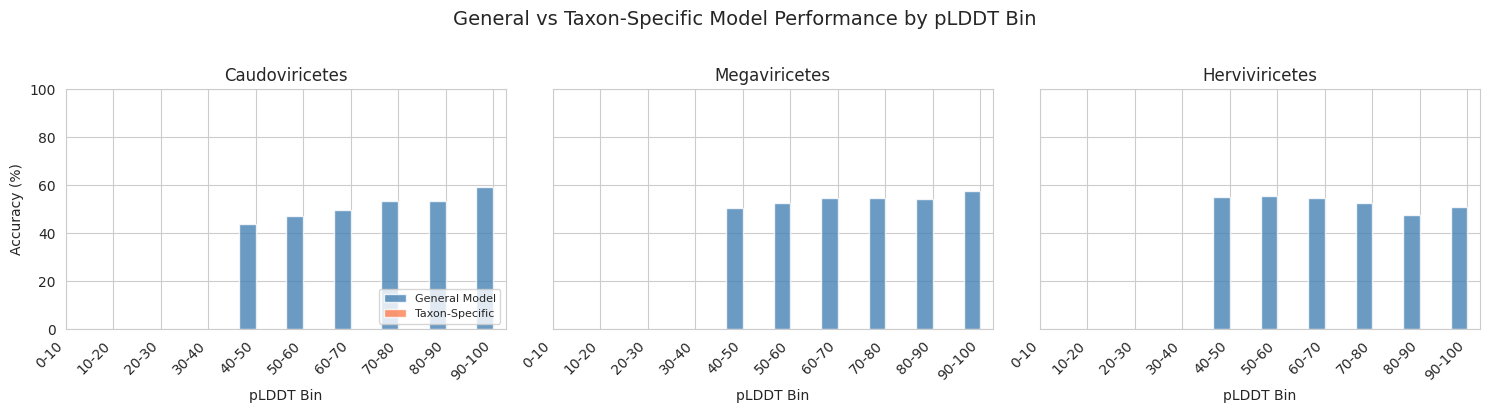

In [70]:
# Visualize general vs taxon-specific performance by pLDDT bin
if cross_taxon_results:
    n_taxa = len(cross_taxon_results)
    fig, axes = plt.subplots(1, n_taxa, figsize=(5*n_taxa, 4), sharey=True)
    if n_taxa == 1:
        axes = [axes]
    
    plddt_bins = range(10)
    bin_labels = [f"{i*10}-{(i+1)*10}" for i in plddt_bins]
    
    for ax, (taxon_name, results) in zip(axes, cross_taxon_results.items()):
        gen_acc = results['general_model']['accuracy_by_bin']
        spec_acc = results['taxon_specific']['accuracy_by_bin'] if results['taxon_specific'] else [np.nan]*10
        
        x = np.arange(10)
        width = 0.35
        
        bars1 = ax.bar(x - width/2, np.array(gen_acc)*100, width, label='General Model', color='steelblue', alpha=0.8)
        bars2 = ax.bar(x + width/2, np.array(spec_acc)*100, width, label='Taxon-Specific', color='coral', alpha=0.8)
        
        ax.set_xlabel('pLDDT Bin')
        ax.set_xticks(x)
        ax.set_xticklabels(bin_labels, rotation=45, ha='right')
        ax.set_title(taxon_name)
        ax.set_ylim(0, 100)
        
        if ax == axes[0]:
            ax.set_ylabel('Accuracy (%)')
            ax.legend(loc='lower right', fontsize=8)
    
    plt.suptitle('General vs Taxon-Specific Model Performance by pLDDT Bin', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('evaluation_results/cross_taxon_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No cross-taxon results to visualize")

## 20. pLDDT Analysis Summary

The pLDDT (predicted Local Distance Difference Test) analysis above reveals several key insights:

### Distribution Findings
- Each viral class has distinct pLDDT distributions reflecting structural diversity
- High pLDDT bins (7-9) represent well-structured regions with confident AlphaFold predictions
- Low pLDDT bins (0-2) often correspond to disordered regions or poorly predicted structures

### Model Performance by pLDDT
- 3Di prediction accuracy strongly correlates with pLDDT confidence
- Higher pLDDT residues show more consistent structural alphabets
- Low pLDDT regions may benefit from additional training data or different loss weighting

### Cross-Taxon Insights
- Taxon-specific models generally outperform general models on their target class
- The performance gap varies by pLDDT bin, with the largest improvements often in mid-range confidence regions
- Cross-taxon evaluation helps identify which classes benefit most from specialized fine-tuning

## 20. BFVD No-Mask pLDDT vs 3Di Histograms

Build a dataset from the BFVD no-mask test set, run ProSTT5 predictions, and plot $\text{pLDDT bin} \times \text{3Di class}$ histograms for untuned and fine-tuned models.

Using AA FASTA: /mnt/data1/bfvd/training_set_nomasking/splits/bfvd_test_aa.fasta
Using 3Di FASTA: /mnt/data1/bfvd/training_set_nomasking/splits/bfvd_test_3di.fasta
Using pLDDT bins FASTA: /mnt/data1/bfvd/training_set_nomasking/splits/bfvd_test_plddt_bin.fasta
Loaded 2000 aligned sequences
Loading checkpoint: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


  Checkpoint: epoch 30, loss: 4.7498
  Label vocab size: 20
  Mask characters: X
  Base model: Rostlab/ProstT5
  Model family: T5 encoder
  Use CNN head: False
  LoRA config: r=32, alpha=64.0, dropout=0.01

⚡ Loading T5-based protein model: Rostlab/ProstT5
   Model type: ProstT5 (bi-directional AA <-> 3Di)
   Using space-separated amino acid tokenization

Loading T5EncoderModel: Rostlab/ProstT5
  Tokenizer: T5Tokenizer (legacy)
✓ Model loaded (hidden_size=1024)

Auto-discovering LoRA target modules...
Discovered 144 target modules
✓ Linear classification head added
Trainable params: 42,570,853 || Total: 1,250,735,205 || Trainable %: 3.40
✓ LoRA setup complete

✓ Checkpoint loaded successfully

Using device: cuda:0
Loading model from: checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt
✓ Checkpoint loaded
✓ Loaded model from epoch 30
Reading input FASTA: evaluation_results/plddt_3di_histograms/bfvd_no_mask_subset_aa.fasta
Found 2000 sequences
Processed 40/2000 sequences
Processed 80/2000 seq

✗ Error running FoldSeek command: Command 'foldseek createdb evaluation_results/plddt_3di_histograms/run_be19d1b9/input_aa.fasta evaluation_results/plddt_3di_histograms/run_be19d1b9/foldseek_db/queryDB --prostt5-model weights --gpu 1' returned non-zero exit status 139.
Traceback (most recent call last):
  File "/tmp/ipykernel_662671/4273253753.py", line 43, in predict_3di_prost5
    output_3di_fasta = pipeline_fn(
  File "/tmp/ipykernel_662671/3248139641.py", line 31, in run_foldseek_prostT5_pipeline
    subprocess.run(cmd1, shell=True, check=True, capture_output=True)
  File "/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/subprocess.py", line 526, in run
    raise CalledProcessError(retcode, process.args,
subprocess.CalledProcessError: Command 'foldseek createdb evaluation_results/plddt_3di_histograms/run_be19d1b9/input_aa.fasta evaluation_results/plddt_3di_histograms/run_be19d1b9/foldseek_db/queryDB --prostt5-model weights --gpu 1' returned non-zero exit status 139.


⚠ Error in ProST T5 prediction: Command 'foldseek createdb evaluation_results/plddt_3di_histograms/run_be19d1b9/input_aa.fasta evaluation_results/plddt_3di_histograms/run_be19d1b9/foldseek_db/queryDB --prostt5-model weights --gpu 1' returned non-zero exit status 139.


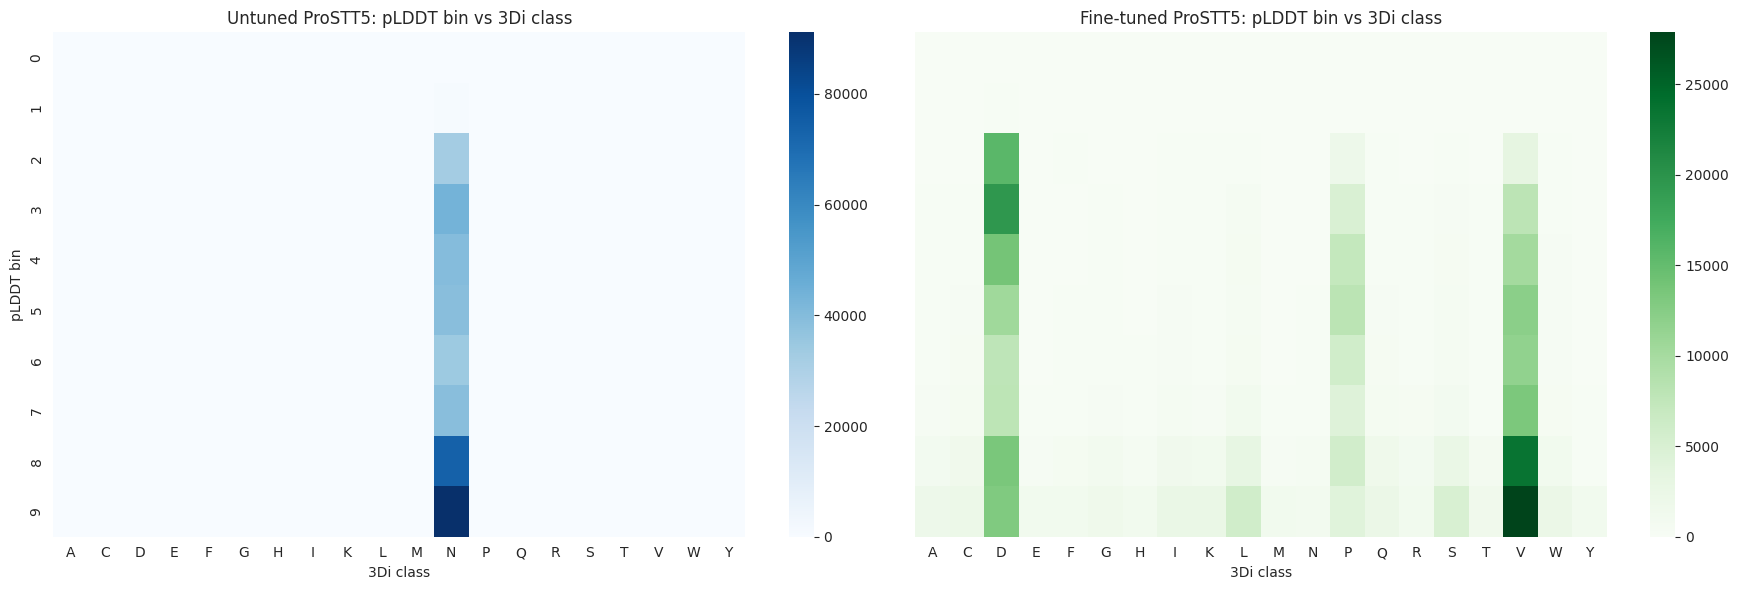

Saved plot to evaluation_results/plddt_3di_histograms/plddt_bin_vs_3di_class_histograms.png


In [ ]:
# Paths for BFVD no-mask test set
NO_MASK_CONFIG = {
    "base_dir": "/mnt/data1/bfvd/training_set_nomasking/splits",
    "max_sequences": 2000,
    "output_dir": os.path.join(EVAL_CONFIG["output_dir"], "plddt_3di_histograms"),
    "finetuned_ckpt": 'checkpoints_prostt5_bfvd_plddt_aux/epoch_30.pt',  # Set to your fine-tuned ProSTT5 checkpoint
    "max_tokens_per_batch": 16000,
}

os.makedirs(NO_MASK_CONFIG["output_dir"], exist_ok=True)

base_dir = Path(NO_MASK_CONFIG["base_dir"])
if not base_dir.exists():
    raise FileNotFoundError(f"Missing directory: {base_dir}")

def _find_one(patterns):
    for pat in patterns:
        matches = sorted(base_dir.glob(pat))
        if matches:
            return matches[0]
    return None

aa_path = _find_one(["*test*aa*.fasta", "*test*aa*.fa"])
three_di_path = _find_one(["*test*3di*.fasta", "*test*3di*.fa"])
plddt_bins_path = _find_one(["*test*plddt*bin*.fasta", "*test*plddt*bin*.fa"])

if aa_path is None or three_di_path is None or plddt_bins_path is None:
    raise FileNotFoundError(
        "Could not locate one or more test files in the splits directory. "
        "Expected patterns: test*aa*.fasta, test*3di*.fasta, test*plddt*bin*.fasta"
    )

print(f"Using AA FASTA: {aa_path}")
print(f"Using 3Di FASTA: {three_di_path}")
print(f"Using pLDDT bins FASTA: {plddt_bins_path}")

# Load sequences and align by header
aa_records = dict(read_fasta(str(aa_path)))
three_di_records = dict(read_fasta(str(three_di_path)))
plddt_records = read_plddt_bins_fasta(str(plddt_bins_path))

common_headers = sorted(set(aa_records) & set(three_di_records) & set(plddt_records))
if NO_MASK_CONFIG["max_sequences"]:
    common_headers = common_headers[: NO_MASK_CONFIG["max_sequences"]]

dataset = []
for h in common_headers:
    aa_seq = aa_records[h]
    three_di_seq = three_di_records[h]
    plddt_seq = plddt_records[h]
    if len(aa_seq) != len(three_di_seq) or len(aa_seq) != len(plddt_seq):
        continue
    dataset.append((h, aa_seq, three_di_seq, plddt_seq))

print(f"Loaded {len(dataset)} aligned sequences")

# Write a subset FASTA for prediction
subset_aa_fasta = os.path.join(NO_MASK_CONFIG["output_dir"], "bfvd_no_mask_subset_aa.fasta")
with open(subset_aa_fasta, "w") as f:
    for h, aa_seq, _, _ in dataset:
        f.write(f">{h}\n{aa_seq}\n")

# Fine-tuned ProSTT5 predictions (model class predict_from_fasta)
if NO_MASK_CONFIG["finetuned_ckpt"] is None:
    raise ValueError("Set EVAL_CONFIG['checkpoint_path'] to the fine-tuned ProSTT5 checkpoint")

finetuned_wrapper, _, finetuned_label_vocab, _, _ = load_checkpoint(
    NO_MASK_CONFIG["finetuned_ckpt"], device=device
 )

finetuned_output_fasta = os.path.join(NO_MASK_CONFIG["output_dir"], "finetuned_prostt5_3di.fasta")
finetuned_preds = finetuned_wrapper.predict_from_fasta(
    input_fasta_path=subset_aa_fasta,
    output_fasta_path=finetuned_output_fasta,
    model_checkpoint_path=NO_MASK_CONFIG["finetuned_ckpt"],
    batch_size=EVAL_CONFIG["batch_size"],
    max_tokens_per_batch=NO_MASK_CONFIG["max_tokens_per_batch"],
    device=device,
 )
finetuned_pred_map = {p["header"]: p["pred_3di"] for p in finetuned_preds}

# Untuned ProSTT5 predictions (FoldSeek pipeline)
untuned_preds_list = predict_3di_prost5(
    [aa_seq for _, aa_seq, _, _ in dataset],
    device=device,
    batch_size=EVAL_CONFIG.get("prost5_batch_size", 1),
    work_dir=NO_MASK_CONFIG["output_dir"],
    cleanup=False,
 )
untuned_pred_map = {h: p for (h, _, _, _), p in zip(dataset, untuned_preds_list)}

if isinstance(finetuned_label_vocab, dict):
    label_vocab = sorted(finetuned_label_vocab.keys())
else:
    label_vocab = list(finetuned_label_vocab)
label_index = {c: i for i, c in enumerate(label_vocab)}

def build_histogram(pred_map):
    hist = np.zeros((10, len(label_vocab)), dtype=np.int64)
    for h, _, _, plddt_seq in dataset:
        pred_seq = pred_map.get(h, "")
        if len(pred_seq) != len(plddt_seq):
            continue
        for pred_char, plddt_char in zip(pred_seq, plddt_seq):
            if not plddt_char.isdigit():
                continue
            pred_upper = pred_char.upper()
            if pred_upper not in label_index:
                continue
            hist[int(plddt_char), label_index[pred_upper]] += 1
	#divide each row by its sum to get percentages
    return hist

untuned_hist = build_histogram(untuned_pred_map)
finetuned_hist = build_histogram(finetuned_pred_map)

# Plot 2D histograms
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
sns.heatmap(untuned_hist, ax=axes[0], cmap="Blues", cbar=True,
            xticklabels=label_vocab, yticklabels=[str(i) for i in range(10)])
axes[0].set_title("Untuned ProSTT5: pLDDT bin vs 3Di class")
axes[0].set_xlabel("3Di class")
axes[0].set_ylabel("pLDDT bin")
sns.heatmap(finetuned_hist, ax=axes[1], cmap="Greens", cbar=True,
            xticklabels=label_vocab, yticklabels=[str(i) for i in range(10)])
axes[1].set_title("Fine-tuned ProSTT5: pLDDT bin vs 3Di class")
axes[1].set_xlabel("3Di class")
plt.tight_layout()

plot_path = os.path.join(NO_MASK_CONFIG["output_dir"], "plddt_bin_vs_3di_class_histograms.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved plot to {plot_path}")